# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 36     |  |
| :-------------|:-------------|
| Oscar Pouw          | 6409806 |
| Elisabeth Mijnders  | 6580971 |
| Lars Mulder         | 6546862 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Elisabeth', 'Oscar','Lars']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| kalibratie af | 12:00 |
| algoritmes bedacht | 14:00 |
| iteratie 0 | 15:30 | 
| iteraties  | 17:00 | 
| laatste checks / inleveren| 17:30| 
| Pauze 1| 12:30-13:45 |
| Pauze 2| 15:45-16:00 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto


kalibratie-opstelling groep [36]
<img src="kalibratie.jpeg" width="400">

0.034379167670892
-0.5209037891730466


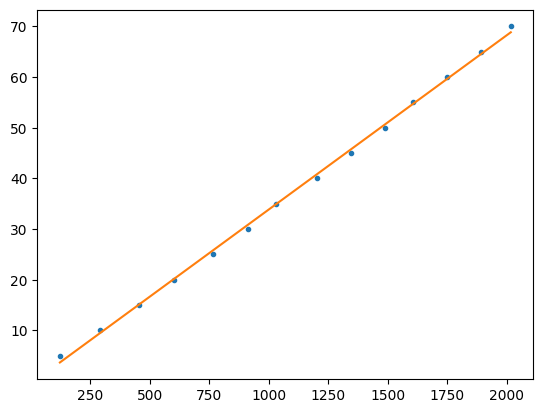

In [3]:
# verwerk hier jullie kalibratiemetingen
afstand = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7 , 0.8,  0.9,   1,    1.1, 1.2, 1.3, 1.4])*50 # cm
arduino = np.array([122, 289, 455, 600, 766, 913, 1032, 1201, 1346, 1491, 1606, 1750, 1894, 2018]) # bits

def fit(x,a,b):
    return a*x+b

val, cov = curve_fit(fit,arduino,afstand)
a = val[0]
b = val[1]

plt.figure
plt.plot( arduino,afstand, "." )
plt.plot(arduino,fit(arduino,*val))
plt.show

print(a)
print(b)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  43.5
1   0  30   0  20  44.1
2  40   0  30   0  41.1
3  30   0  20   0  40.5


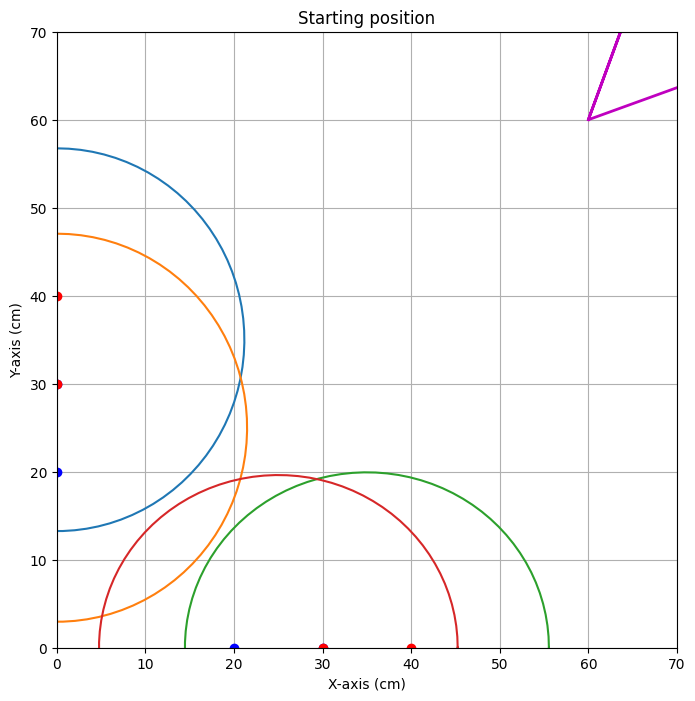


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.655


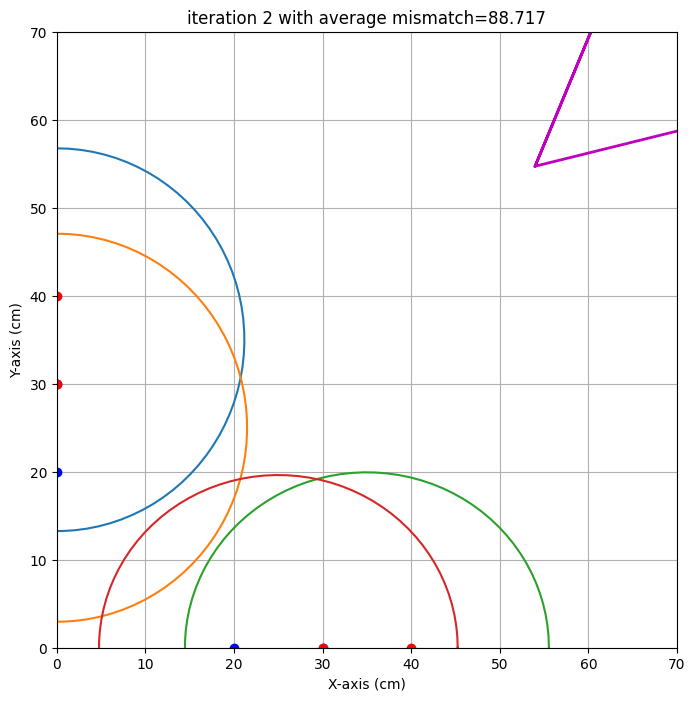

end iteration 2 with average mismatch=88.717


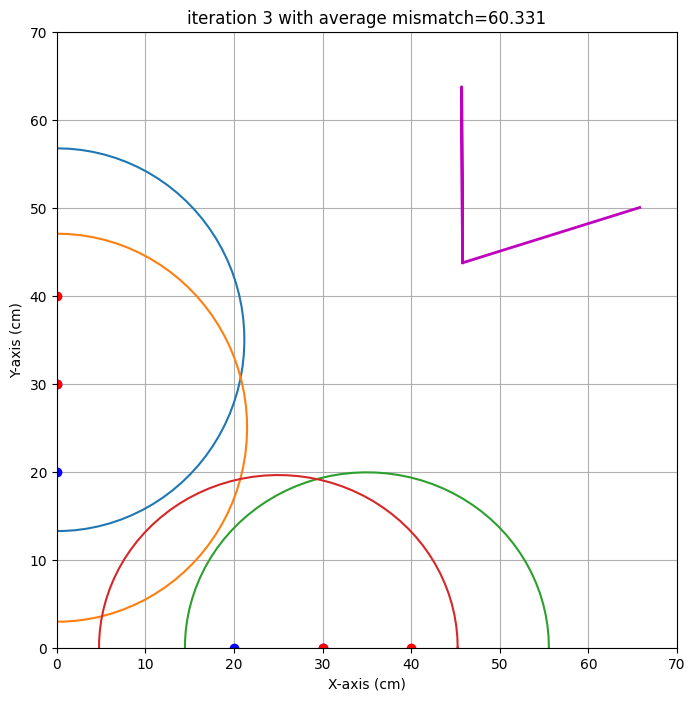

end iteration 3 with average mismatch=60.331


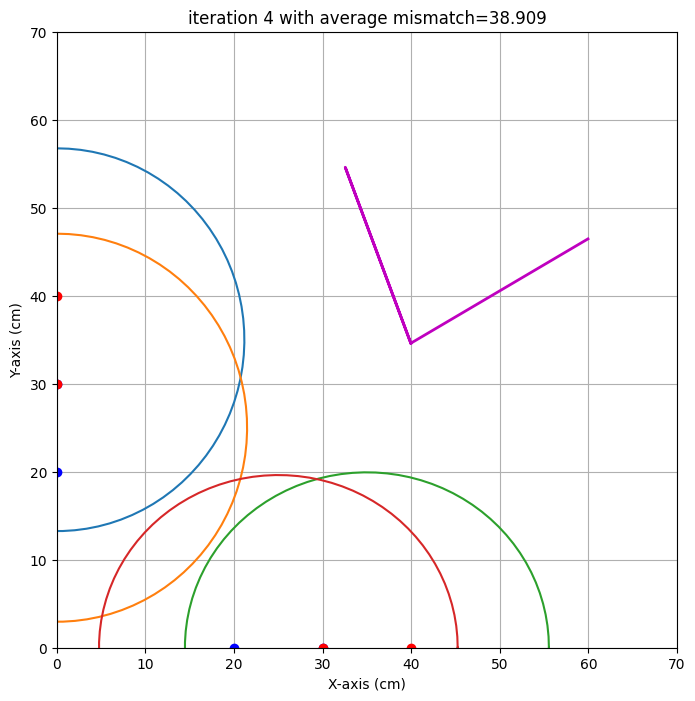

end iteration 4 with average mismatch=38.909


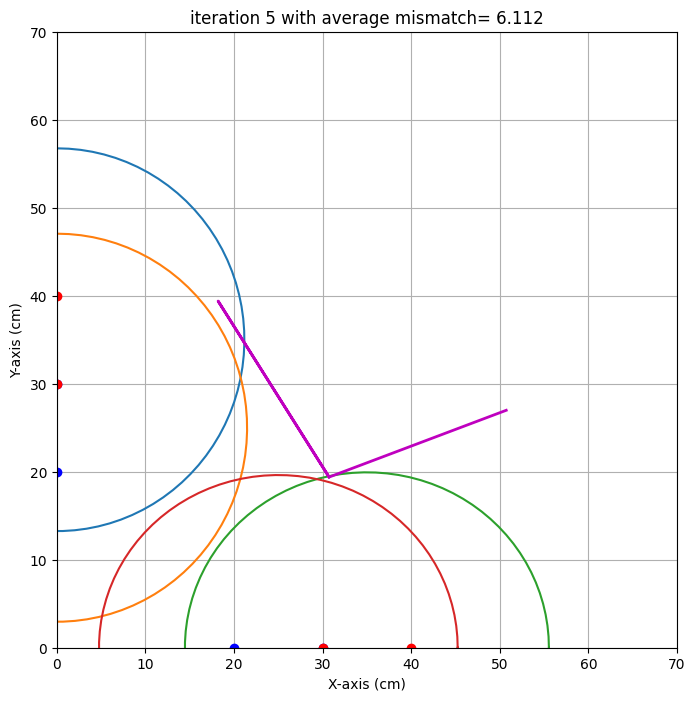

end iteration 5 with average mismatch= 6.112


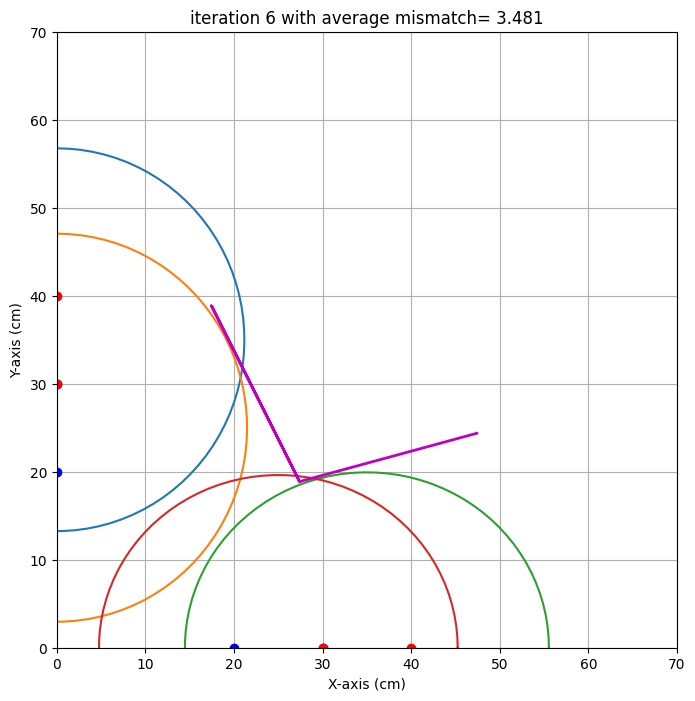

end iteration 6 with average mismatch= 3.481


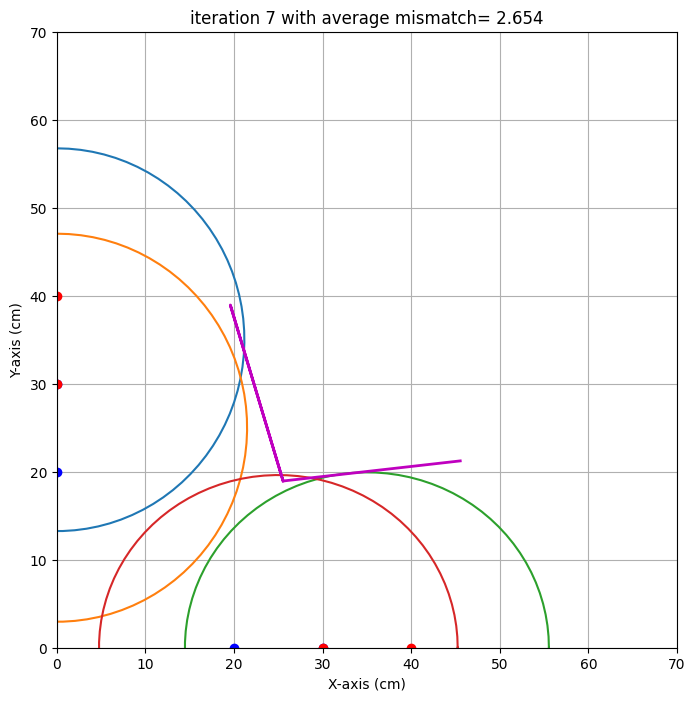

end iteration 7 with average mismatch= 2.654


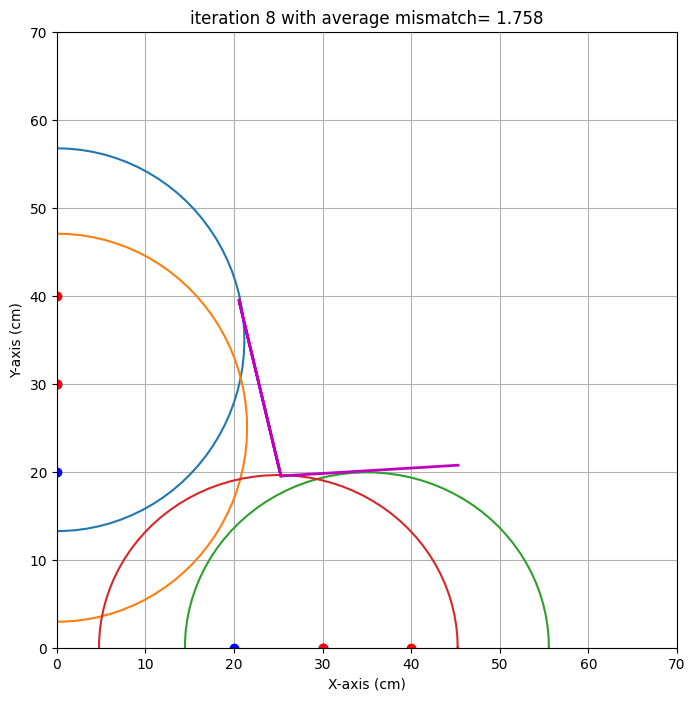

end iteration 8 with average mismatch= 1.758


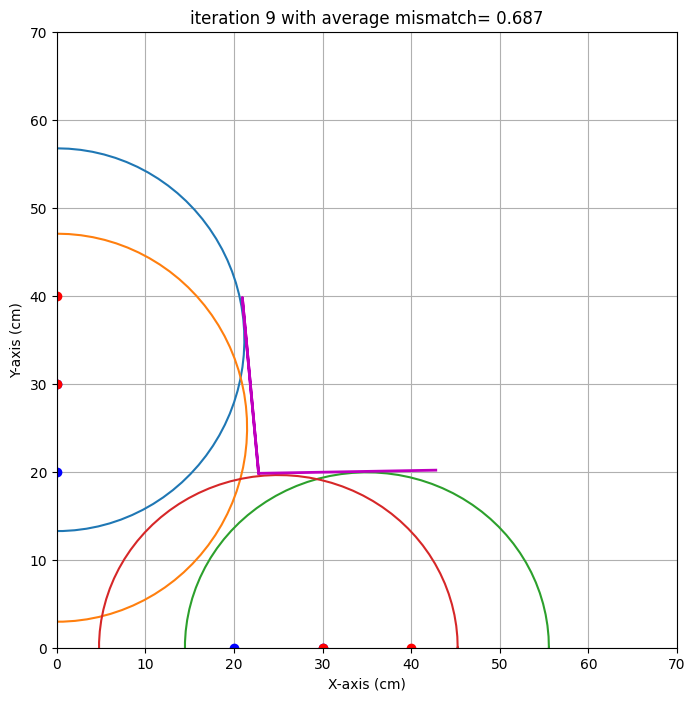

end iteration 9 with average mismatch= 0.687


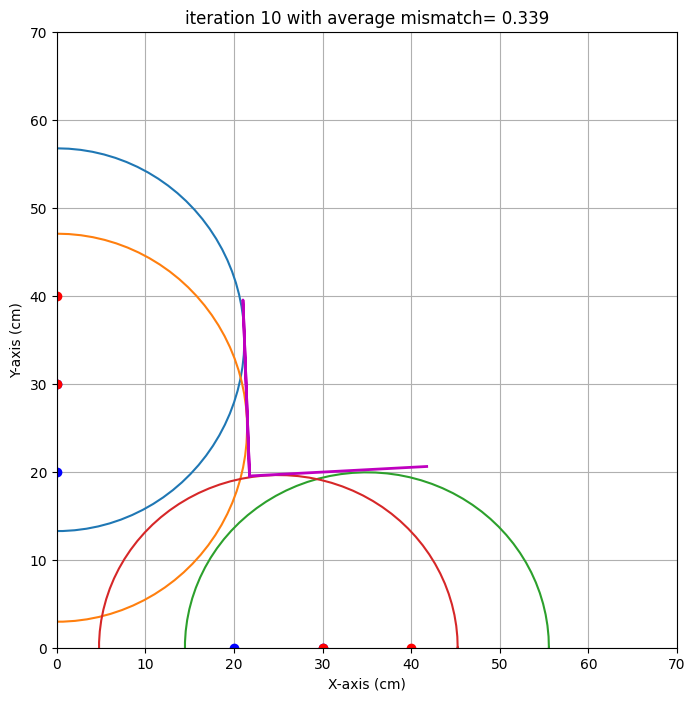

end iteration 10 with average mismatch= 0.339
end iteration 11 with average mismatch= 0.316
end iteration 12 with average mismatch= 0.303
end iteration 13 with average mismatch= 0.303
end iteration 14 with average mismatch= 0.303
end iteration 15 with average mismatch= 0.303
end iteration 16 with average mismatch= 0.303
end iteration 17 with average mismatch= 0.303
end iteration 18 with average mismatch= 0.303
end iteration 19 with average mismatch= 0.303
end iteration 20 with average mismatch= 0.303
end iteration 21 with average mismatch= 0.303
end iteration 22 with average mismatch= 0.303
end iteration 23 with average mismatch= 0.303
end iteration 24 with average mismatch= 0.303
end iteration 25 with average mismatch= 0.303
end iteration 26 with average mismatch= 0.295


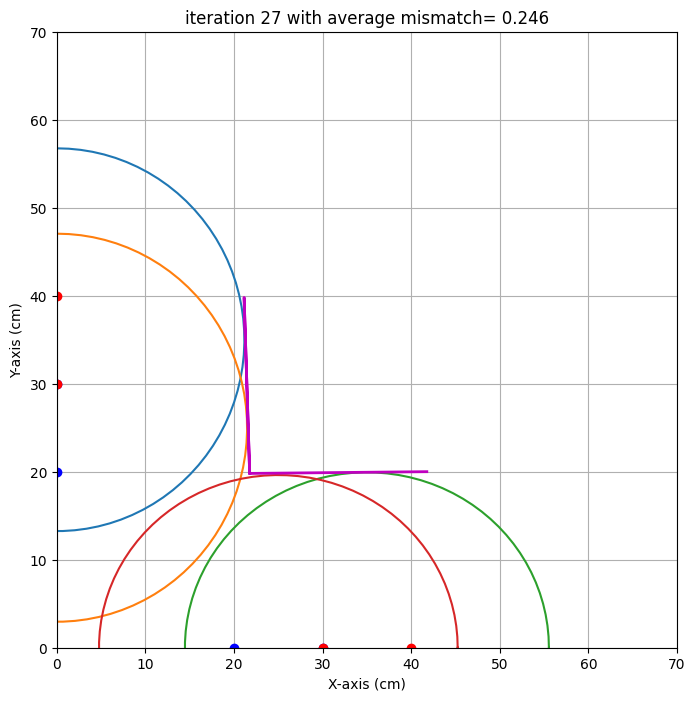

end iteration 27 with average mismatch= 0.246
end iteration 28 with average mismatch= 0.230
end iteration 29 with average mismatch= 0.228
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.227
###############################################################################
end of iteration  30
Best alpha=   0.57 with uncertainty=   2.14
Best beta =  -1.81 with uncertainty=   3.06
Best x0   =  21.75 with uncertainty=   0.48
Best y0   =  19.79 with uncertainty=   0.29
###############################################################################


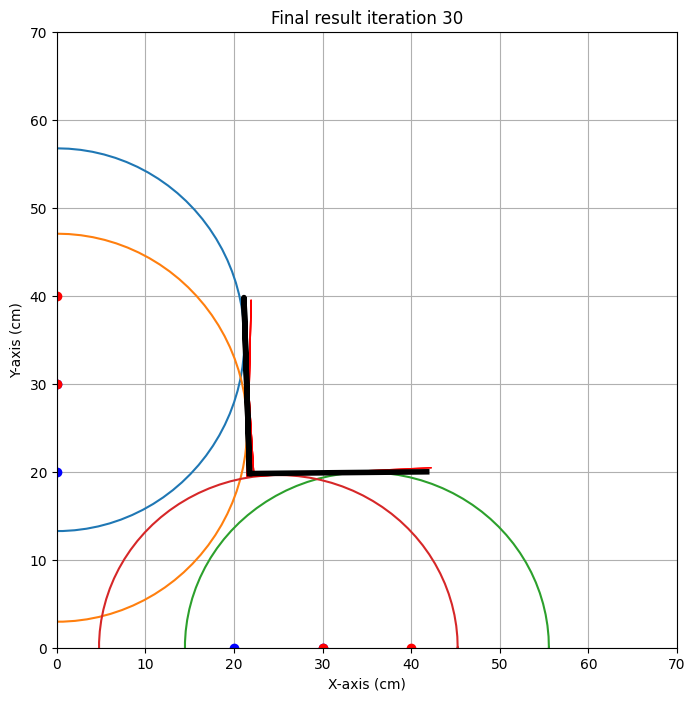

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,43.5],
    [0,30,0,20,44.1],
    #[0,10,0,20,ongeldig],
    [40,0,30,0,41.1],
    [30,0,20,0,40.5],
    #[10,0,20,0,ongeldig],
    #[10,0,0,10,ongeldig]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.8 cm met een standaardafwijking van 0.5 cm 
y0: 19.8 cm met een standaardafwijking van 0.3 cm 
alpha: 0.6 graden met een standaardafwijking van 2.1 graad 
beta: -1.8 graden met een standaardafwijking van 3.1 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Lars Mulder]
<img src="Algoritme_Lars.jpeg" width="400">

#### algoritme [Elisabeth Mijnders]
<img src="Algoritme_Elisabeth.jpeg" width="400">

#### algoritme [Oscar Pouw]
<img src="Algoritme_Oscar.jpg" width="400">


## Opdracht 6: Test iteratie 0.

In [6]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 26.5,  
           'y0': 34.5,
           'alpha' : 13 ,
           'beta' : 13 ,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Lars' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,70,0,60,68],
    [0,60,0,50,59.2],
    [0,50,0,40,54.1],
    #[0,40,0,30,],
    #[0,30,0,20,],
    #[0,20,0,10,],
    #[0,10,0,20,],
    #[70,0,60,0,],
    [60,0,50,0,79],
    [50,0,40,0,75.8],
    [40,0,30,0,71.6],
    #[30,0,20,0,],
    #[20,0,10,0,0],
    #[10,0,20,0,0],
    
    ]),
       'Elisabeth' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[25,0,35,0,ongeldig],
    [35,0,45,0,72.6],
    [40,0,50,0,74.9],
   # [0,25,0,35,ongeldig],
    [0,35,0,45,55.5],
    [0,40,0,50,54.5],

    ]),
       'Oscar' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,50,0,74.1],
    [50,0,60,0,79.1],
    [60,0,70,0,86.5],
    [30,0,40,0,71],
    #[20,0,30,0,ongeldig],
    [0,40,0,50,53],
    [0,50,0,60,60],
    [0,60,0,70,67],
    #[0,30,0,40,ongeldig],
    
    ]),
      }

## Opdracht 7: Evaluatie.

Elisabeth
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  35   0  45   0  72.6
1  40   0  50   0  74.9
2   0  35   0  45  55.5
3   0  40   0  50  54.5


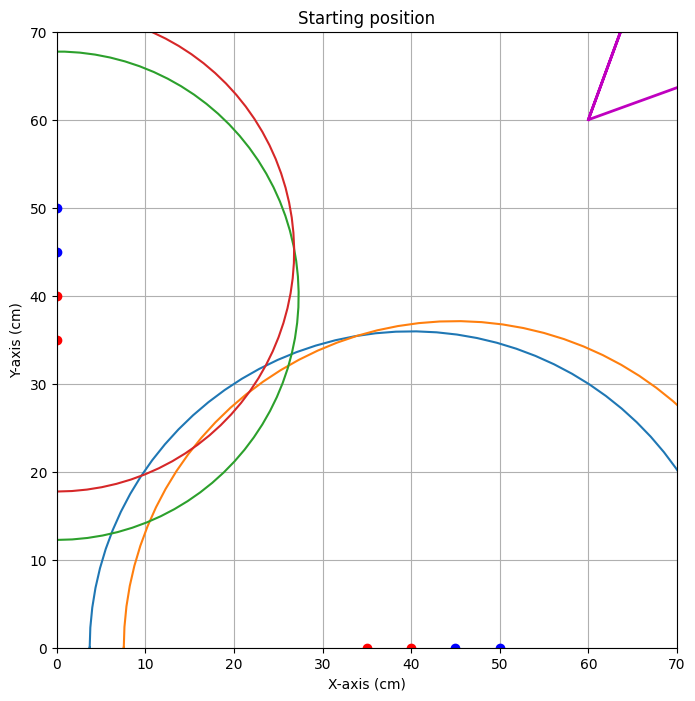


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=67.723


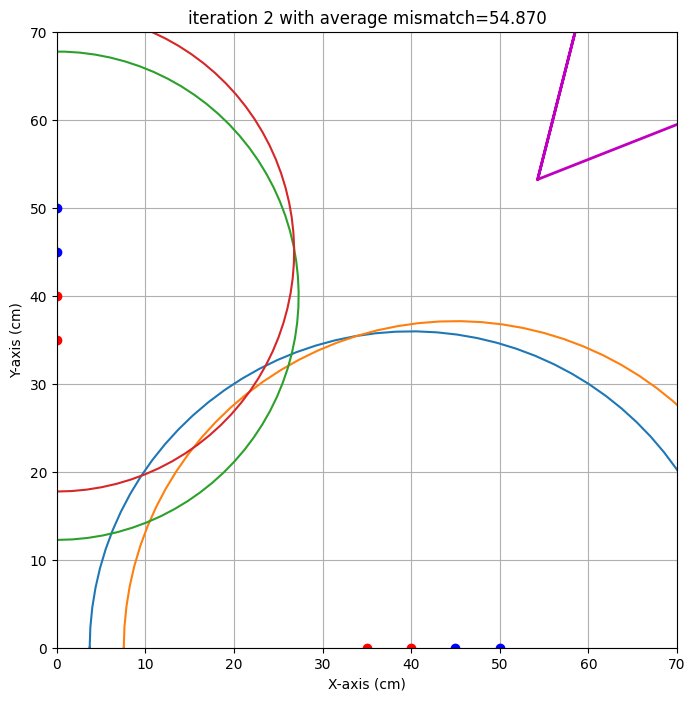

end iteration 2 with average mismatch=54.870


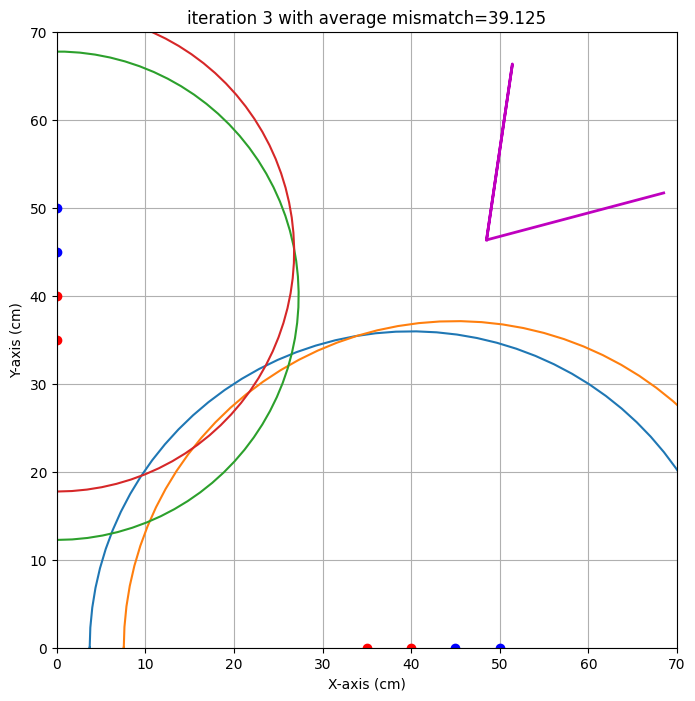

end iteration 3 with average mismatch=39.125


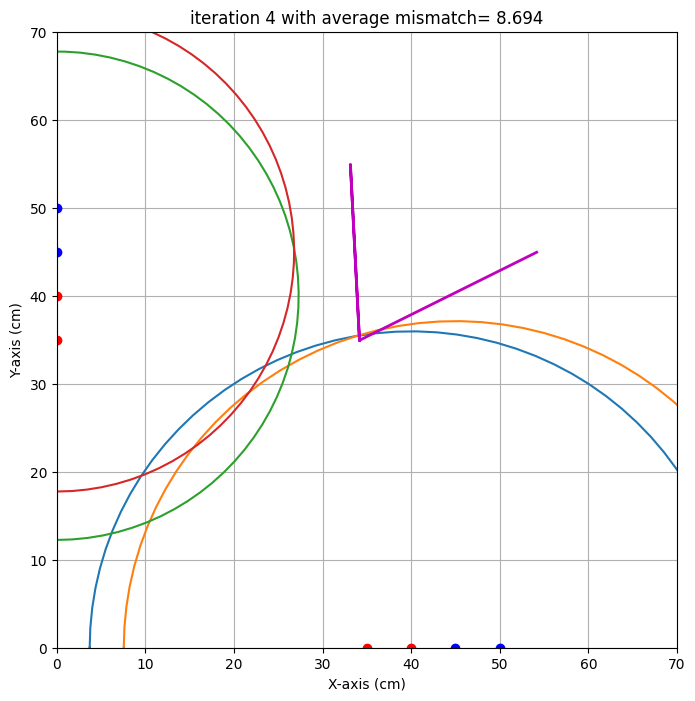

end iteration 4 with average mismatch= 8.694


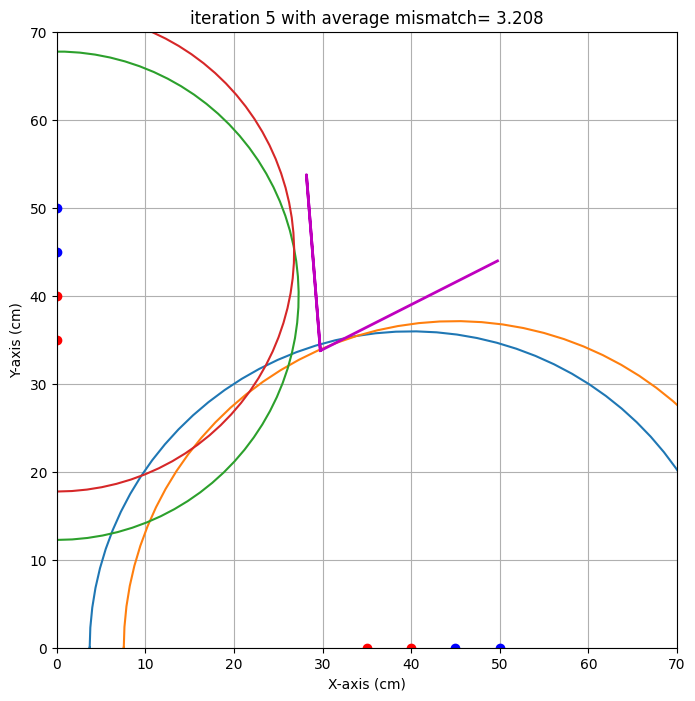

end iteration 5 with average mismatch= 3.208


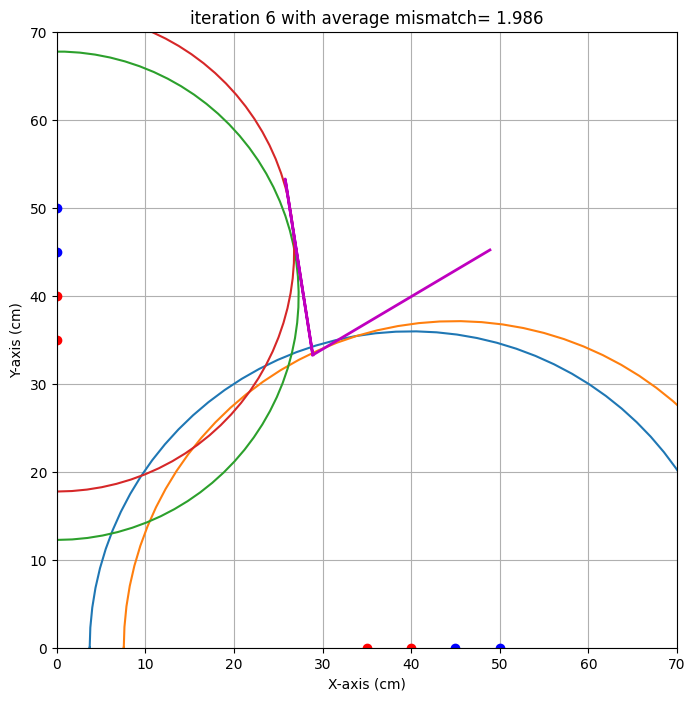

end iteration 6 with average mismatch= 1.986


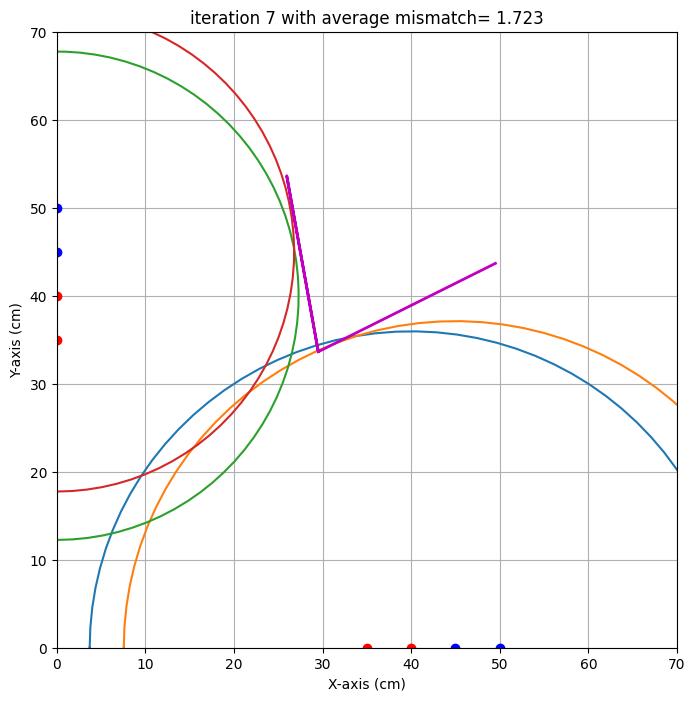

end iteration 7 with average mismatch= 1.723


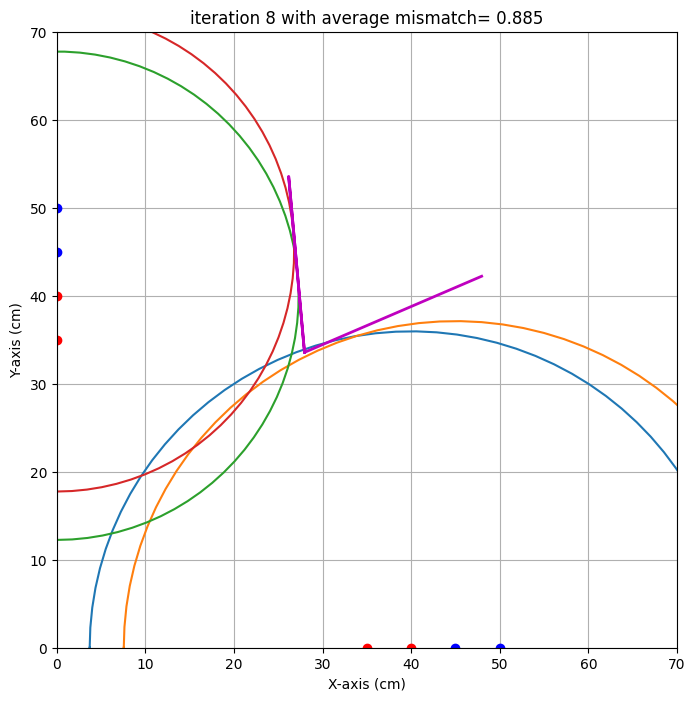

end iteration 8 with average mismatch= 0.885
end iteration 9 with average mismatch= 0.809
end iteration 10 with average mismatch= 0.740
end iteration 11 with average mismatch= 0.738
end iteration 12 with average mismatch= 0.728
end iteration 13 with average mismatch= 0.667


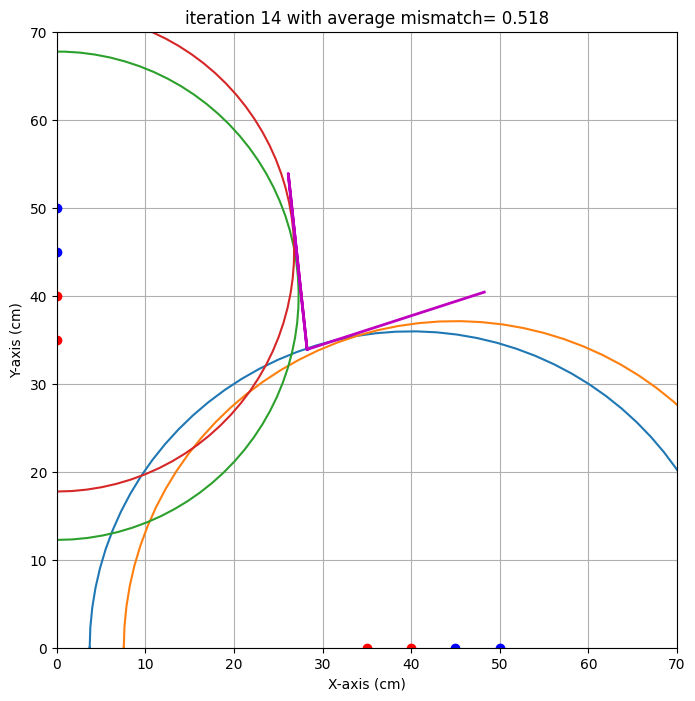

end iteration 14 with average mismatch= 0.518


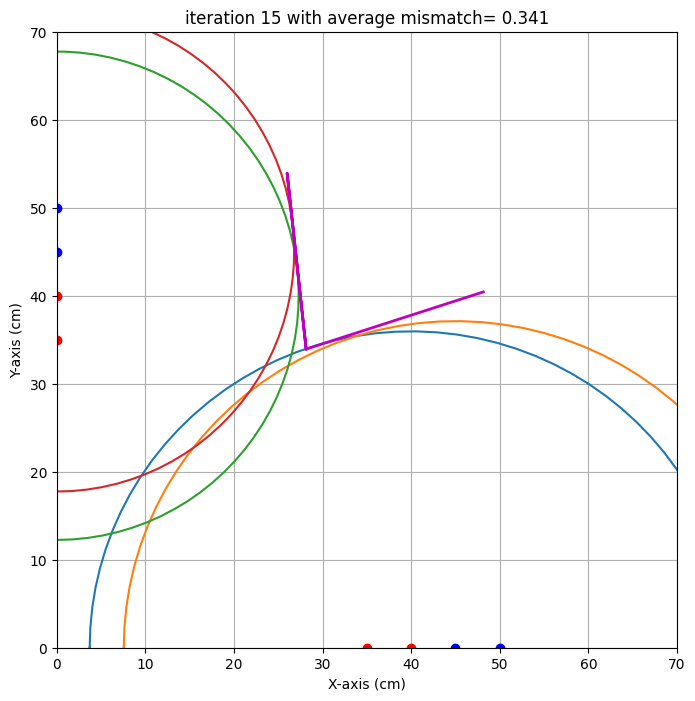

end iteration 15 with average mismatch= 0.341
end iteration 16 with average mismatch= 0.338


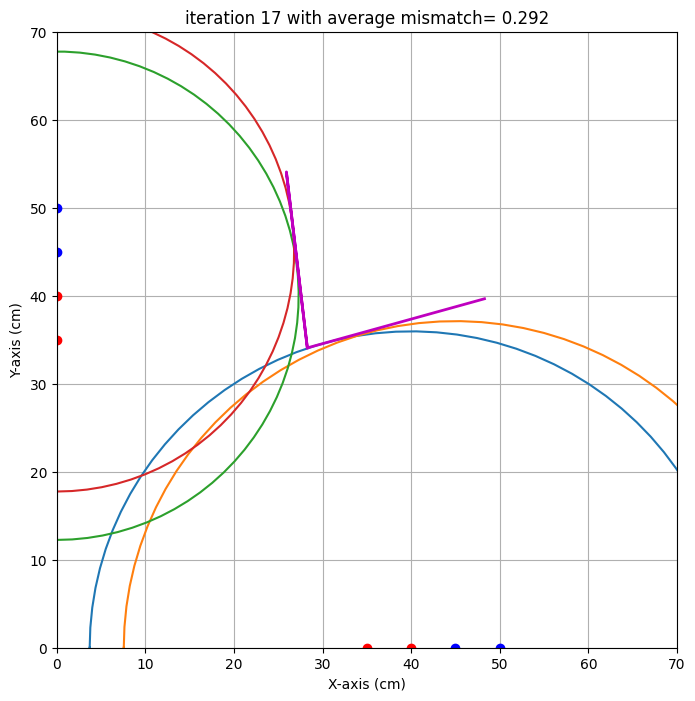

end iteration 17 with average mismatch= 0.292
end iteration 18 with average mismatch= 0.289


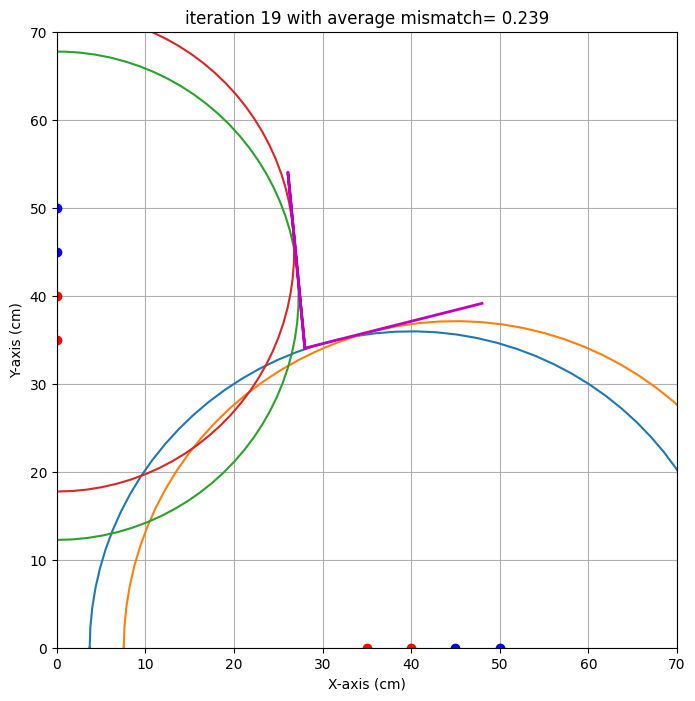

end iteration 19 with average mismatch= 0.239
end iteration 20 with average mismatch= 0.237
end iteration 21 with average mismatch= 0.237
end iteration 22 with average mismatch= 0.237
end iteration 23 with average mismatch= 0.237
end iteration 24 with average mismatch= 0.237


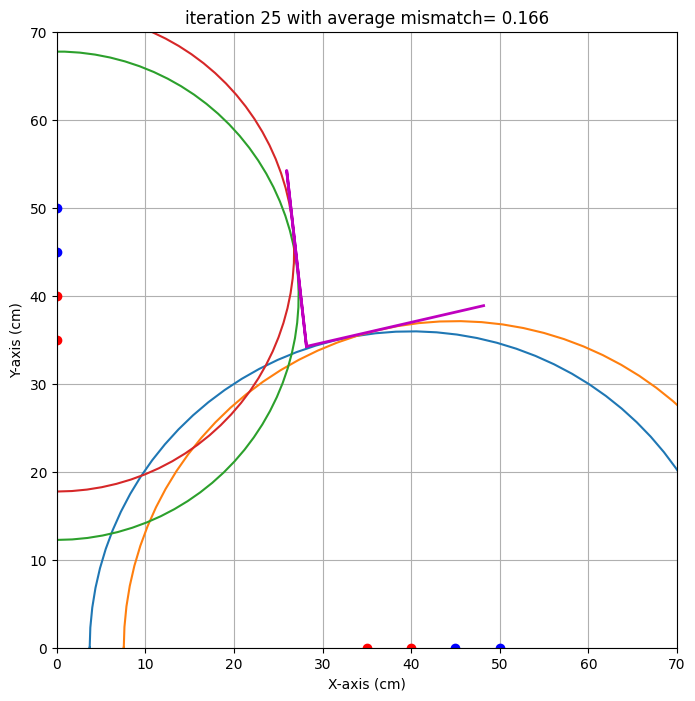

end iteration 25 with average mismatch= 0.166


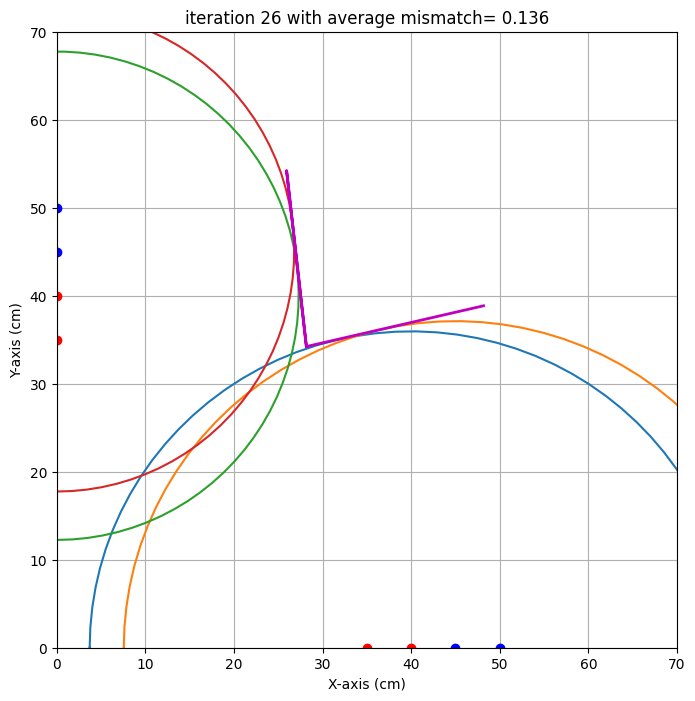

end iteration 26 with average mismatch= 0.136
end iteration 27 with average mismatch= 0.131
end iteration 28 with average mismatch= 0.130
end iteration 29 with average mismatch= 0.129
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.129
###############################################################################
end of iteration  30
Best alpha=  13.04 with uncertainty=   3.18
Best beta =  -6.39 with uncertainty=   1.64
Best x0   =  28.16 with uncertainty=   0.39
Best y0   =  34.22 with uncertainty=   0.61
###############################################################################


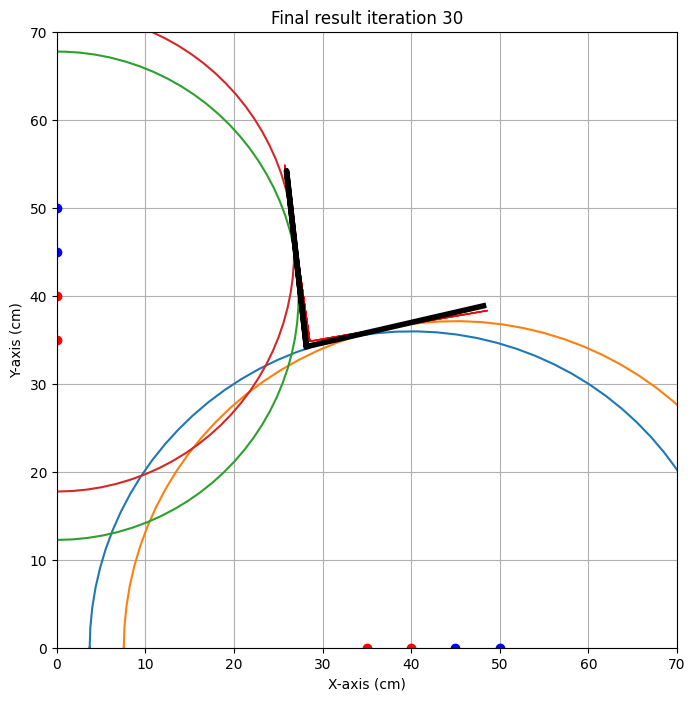

{'alpha': np.float64(13.040143846087146), 'alpha_eps': np.float64(3.1765098811805306), 'beta': np.float64(-6.386101283716115), 'beta_eps': np.float64(1.638169561294375), 'x0': np.float64(28.160419538185977), 'x0_eps': np.float64(0.38888591733595845), 'y0': np.float64(34.216687258314636), 'y0_eps': np.float64(0.608333672993453)}
Oscar
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  74.1
1  50   0  60   0  79.1
2  60   0  70   0  86.5
3  30   0  40   0  71.0
4   0  40   0  50  53.0
5   0  50   0  60  60.0
6   0  60   0  70  67.0


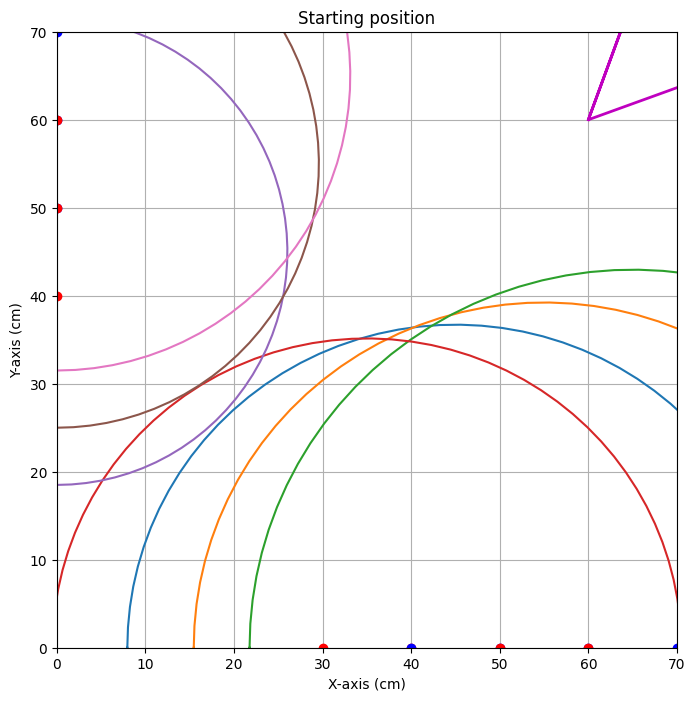


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=59.175


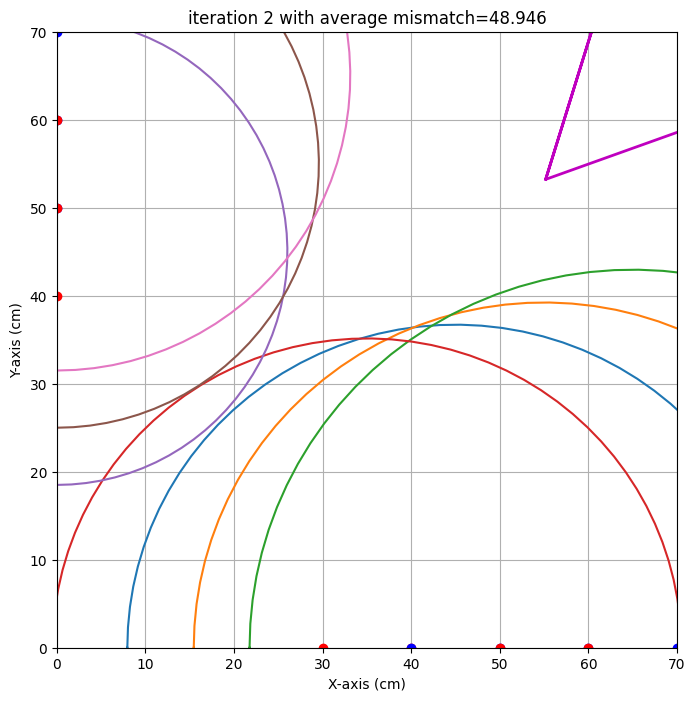

end iteration 2 with average mismatch=48.946


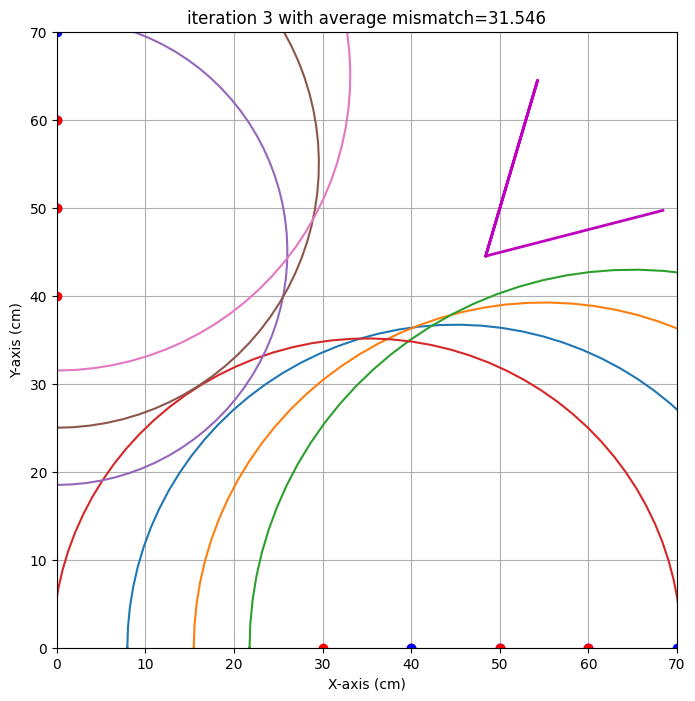

end iteration 3 with average mismatch=31.546


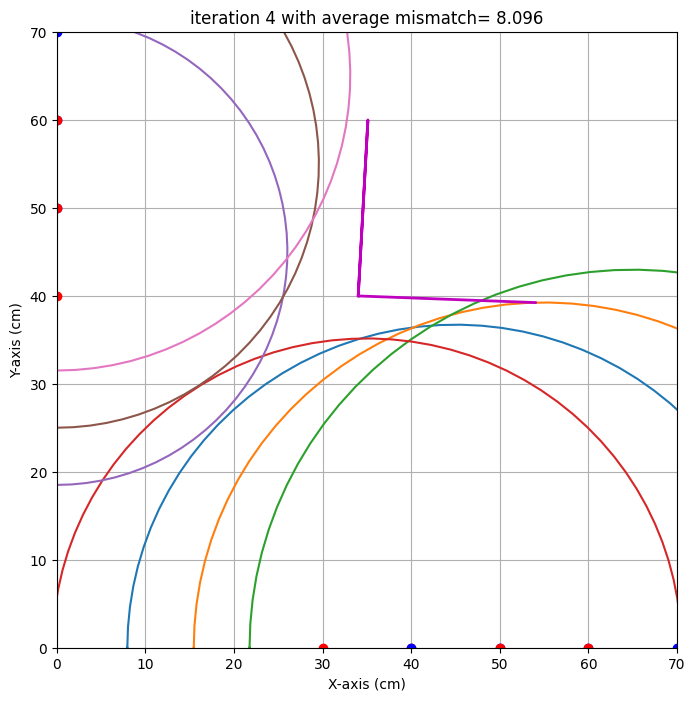

end iteration 4 with average mismatch= 8.096


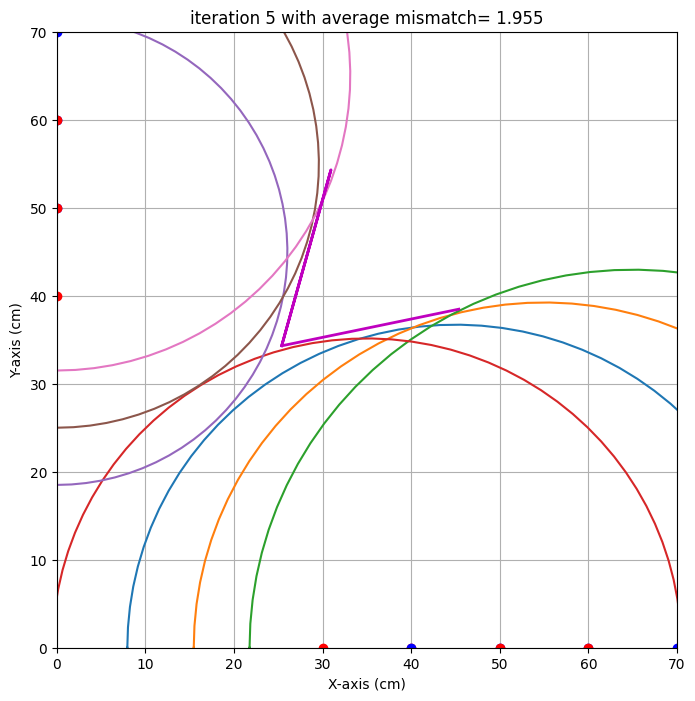

end iteration 5 with average mismatch= 1.955


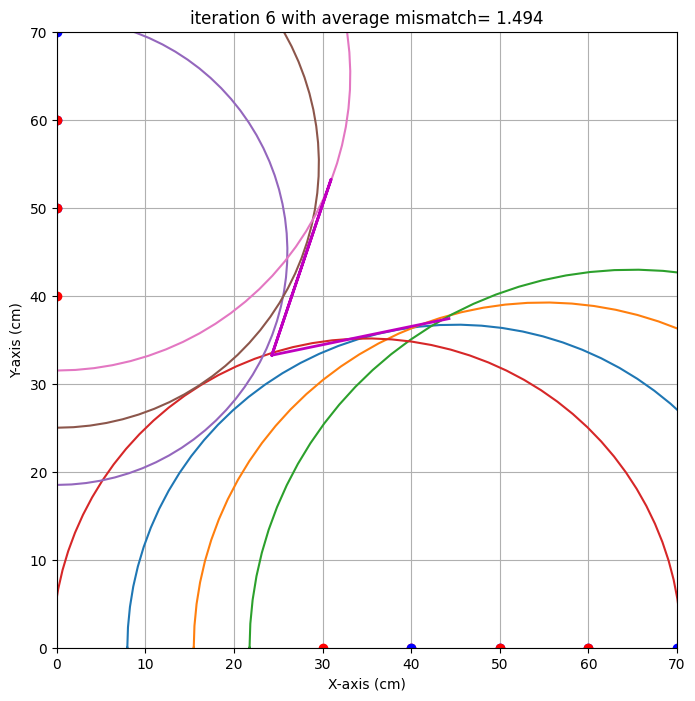

end iteration 6 with average mismatch= 1.494


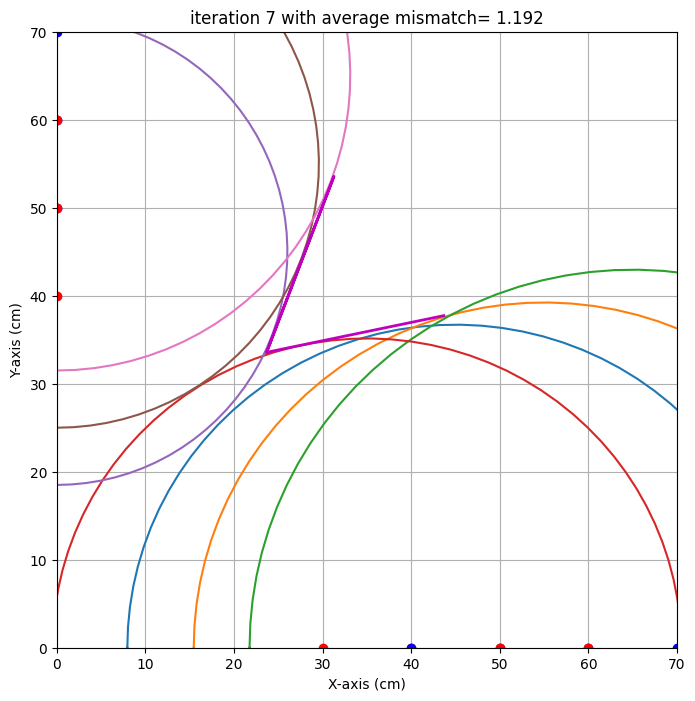

end iteration 7 with average mismatch= 1.192
end iteration 8 with average mismatch= 1.164
end iteration 9 with average mismatch= 1.151
end iteration 10 with average mismatch= 1.149
end iteration 11 with average mismatch= 1.149
end iteration 12 with average mismatch= 1.149
end iteration 13 with average mismatch= 1.149
end iteration 14 with average mismatch= 1.149
end iteration 15 with average mismatch= 1.149
end iteration 16 with average mismatch= 1.120
end iteration 17 with average mismatch= 1.119
end iteration 18 with average mismatch= 1.119
end iteration 19 with average mismatch= 1.119
end iteration 20 with average mismatch= 1.119
end iteration 21 with average mismatch= 1.119
end iteration 22 with average mismatch= 1.119
end iteration 23 with average mismatch= 1.119
end iteration 24 with average mismatch= 1.119
end iteration 25 with average mismatch= 1.119
end iteration 26 with average mismatch= 1.119
end iteration 27 with average mismatch= 1.119
end iteration 28 with average mismatc

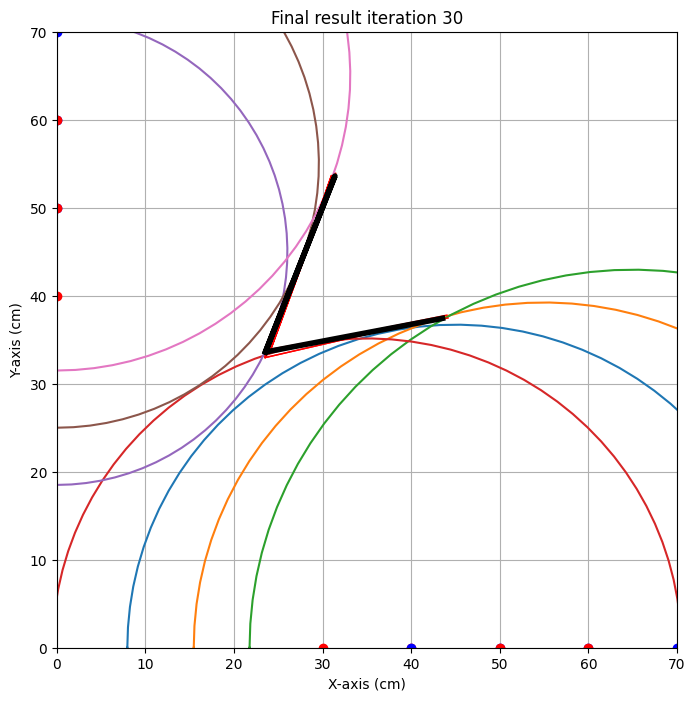

{'alpha': np.float64(10.849716835051481), 'alpha_eps': np.float64(2.1569069520439026), 'beta': np.float64(21.436274841684305), 'beta_eps': np.float64(2.2453618592163593), 'x0': np.float64(23.536243732963797), 'x0_eps': np.float64(0.6332975122576983), 'y0': np.float64(33.597128931916835), 'y0_eps': np.float64(0.630149577872082)}
Lars
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  70   0  60  68.0
1   0  60   0  50  59.2
2   0  50   0  40  54.1
3  60   0  50   0  79.0
4  50   0  40   0  75.8
5  40   0  30   0  71.6


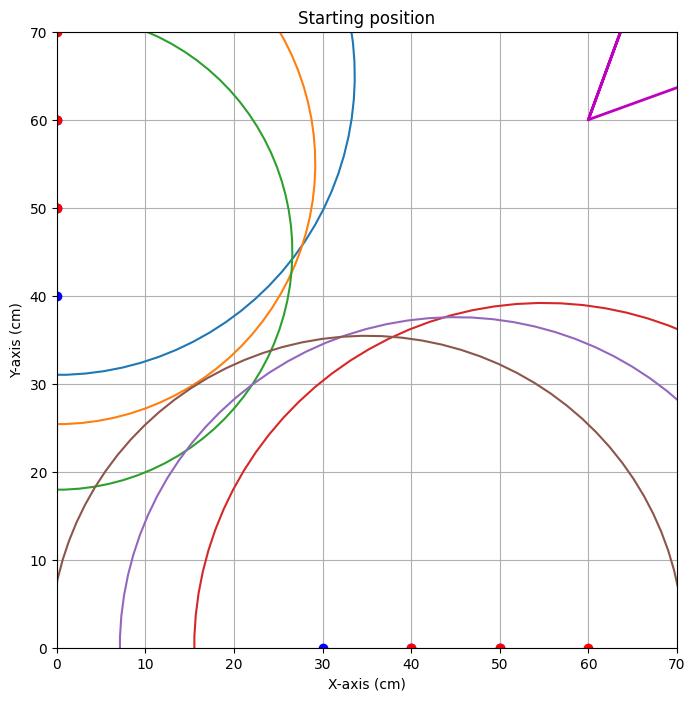


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=61.265


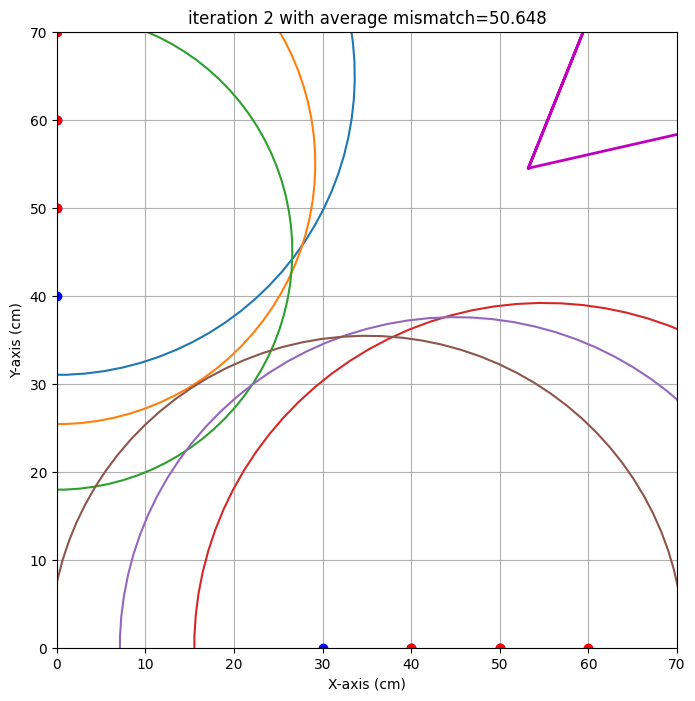

end iteration 2 with average mismatch=50.648


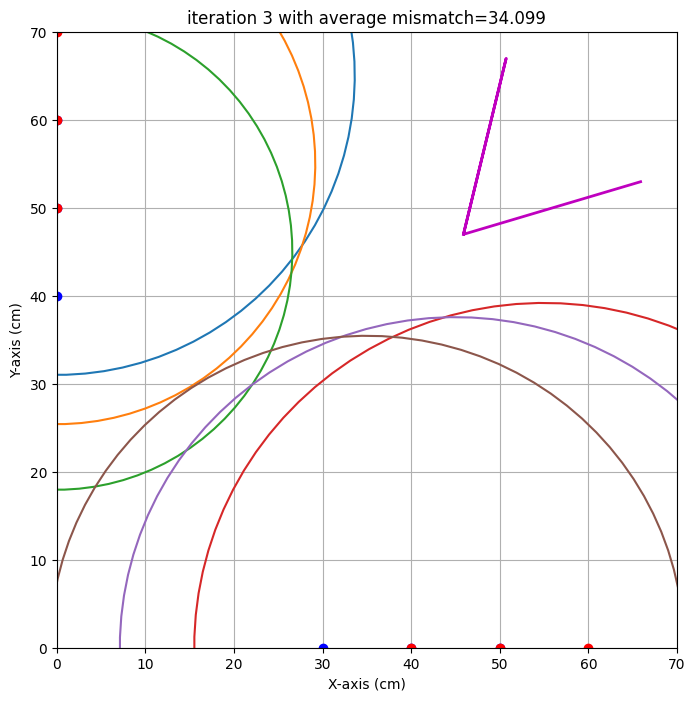

end iteration 3 with average mismatch=34.099


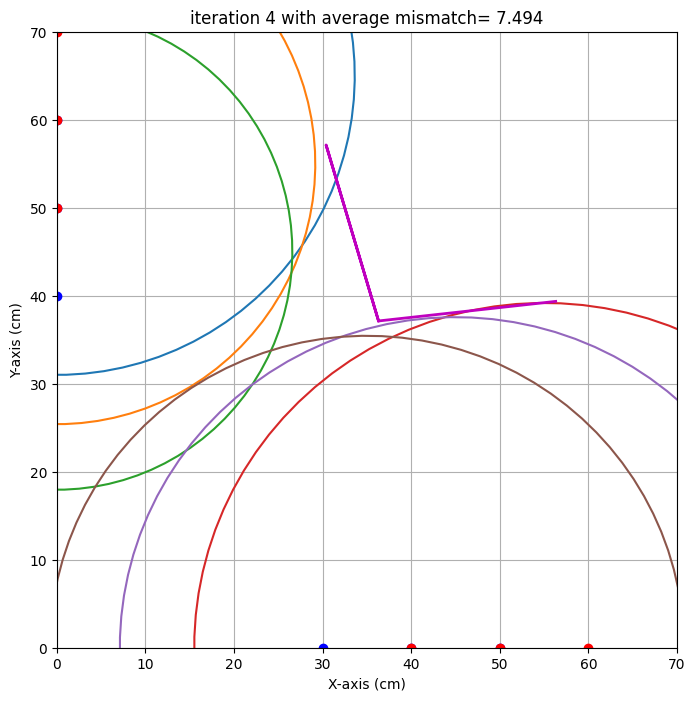

end iteration 4 with average mismatch= 7.494


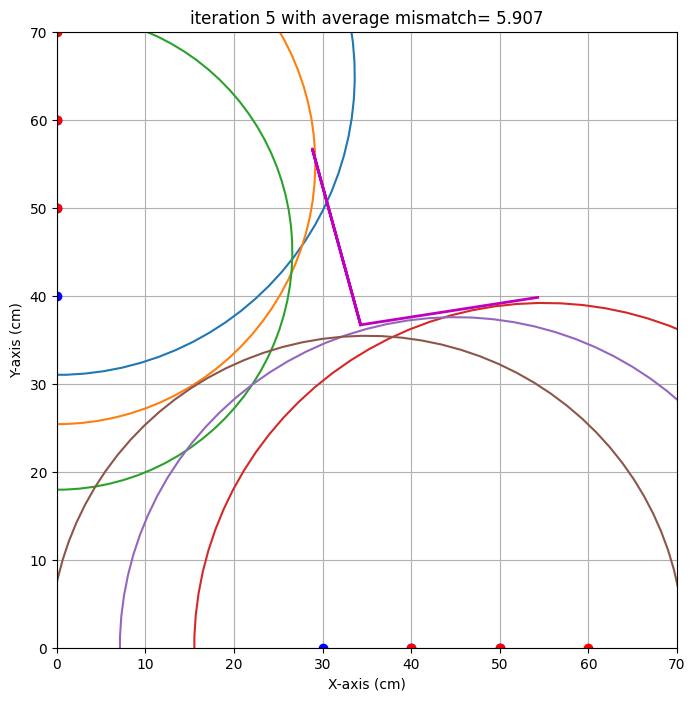

end iteration 5 with average mismatch= 5.907


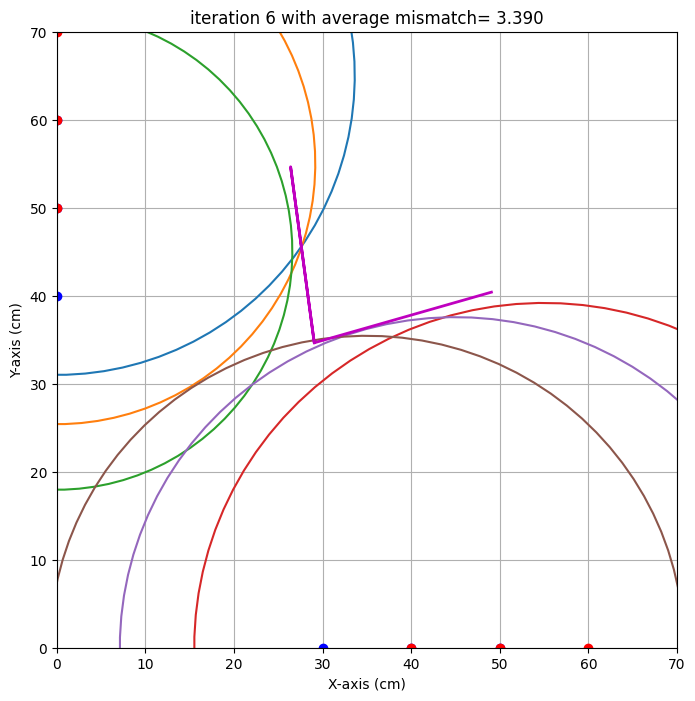

end iteration 6 with average mismatch= 3.390


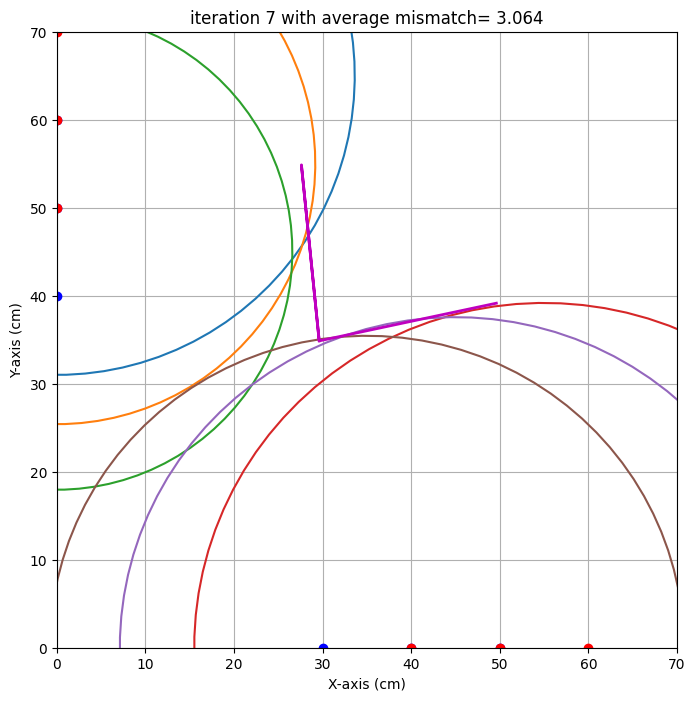

end iteration 7 with average mismatch= 3.064


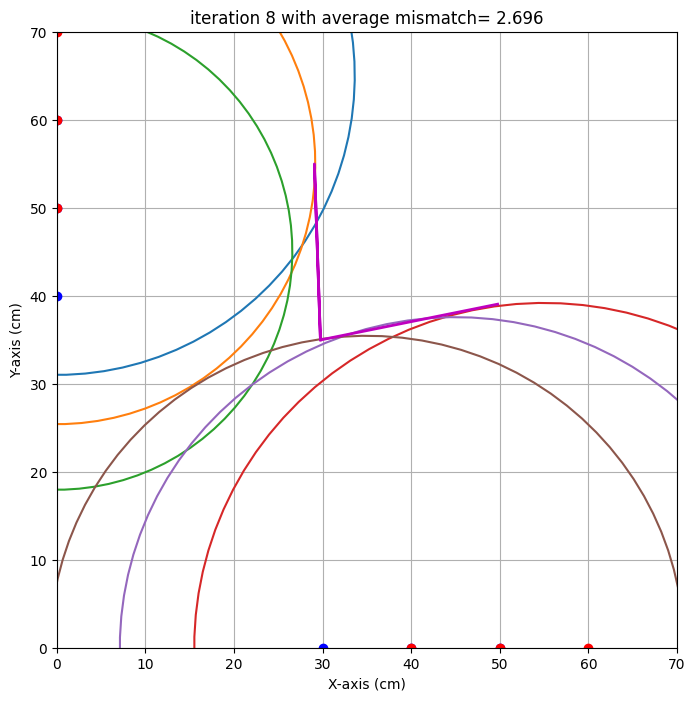

end iteration 8 with average mismatch= 2.696
end iteration 9 with average mismatch= 2.696


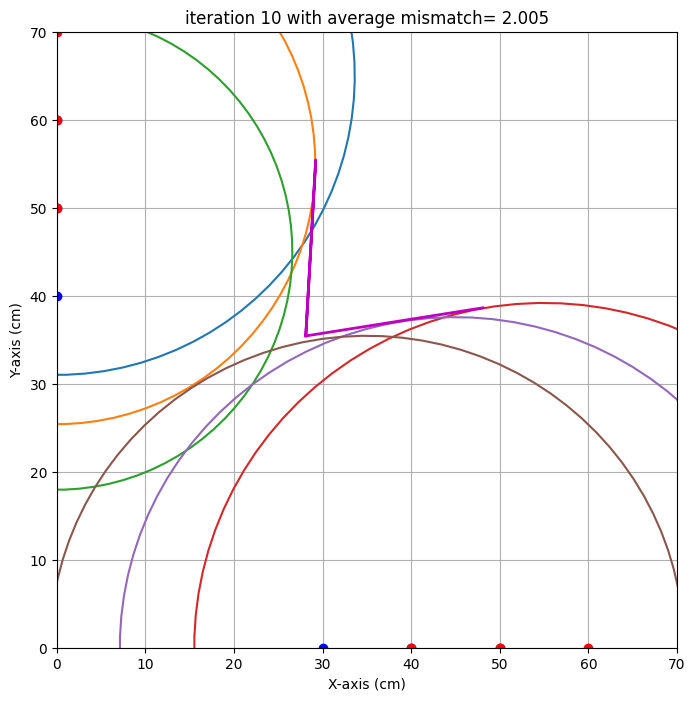

end iteration 10 with average mismatch= 2.005


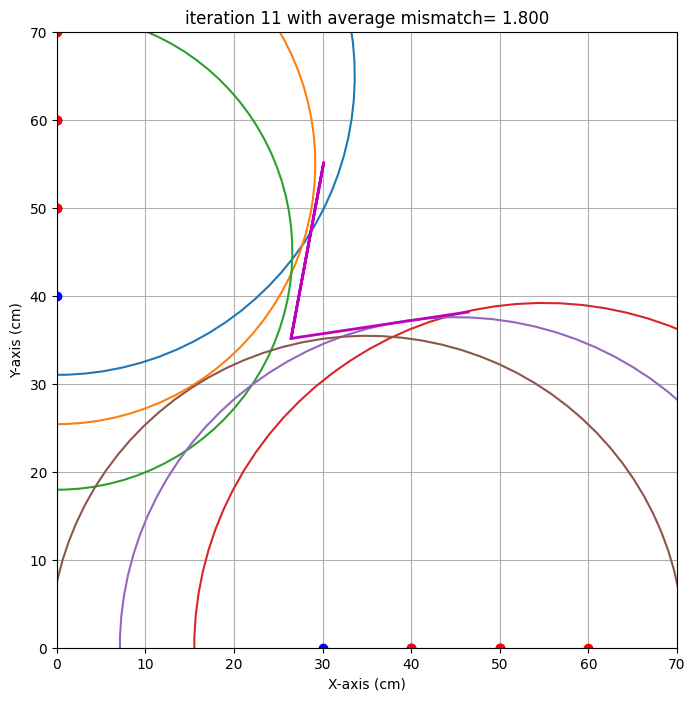

end iteration 11 with average mismatch= 1.800


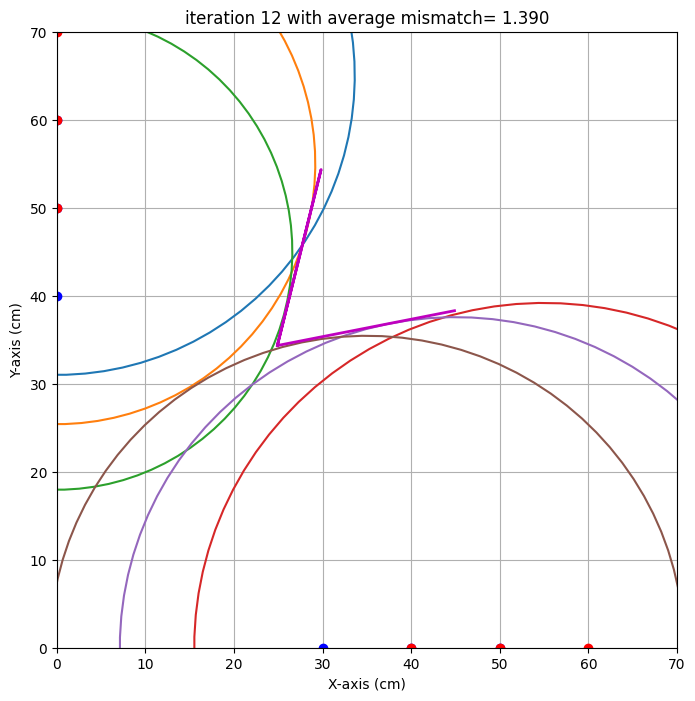

end iteration 12 with average mismatch= 1.390
end iteration 13 with average mismatch= 1.320
end iteration 14 with average mismatch= 1.258


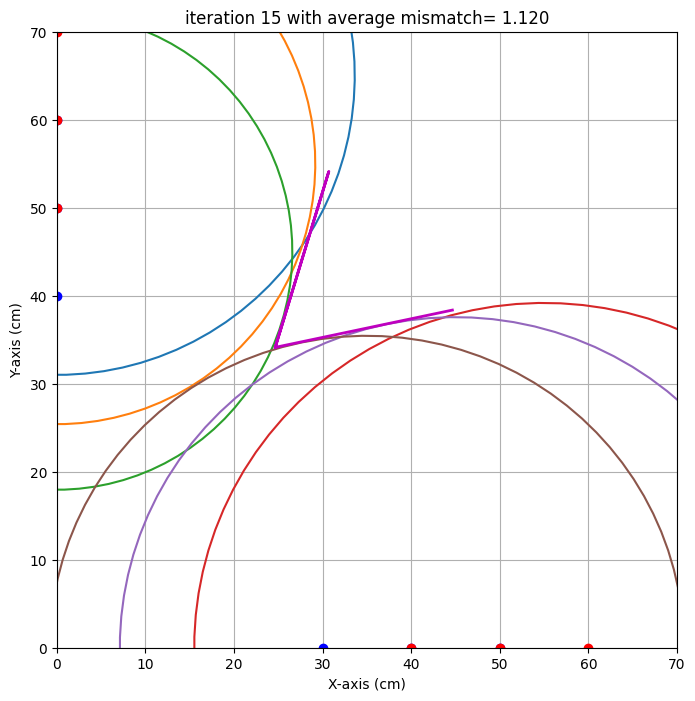

end iteration 15 with average mismatch= 1.120
end iteration 16 with average mismatch= 1.096
end iteration 17 with average mismatch= 1.069


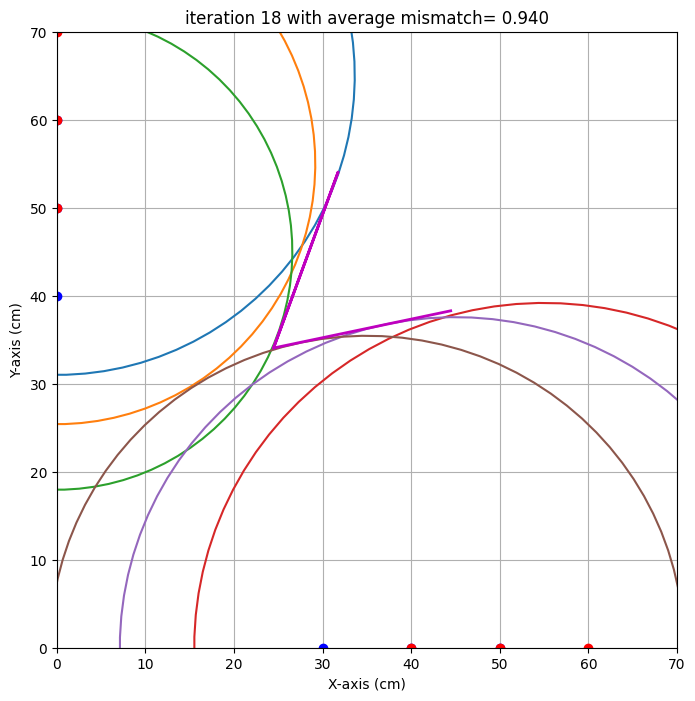

end iteration 18 with average mismatch= 0.940


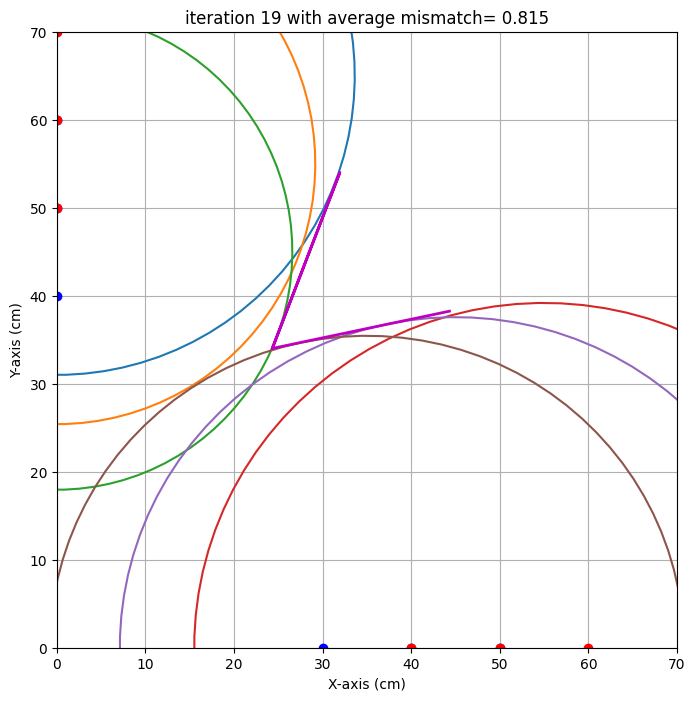

end iteration 19 with average mismatch= 0.815
end iteration 20 with average mismatch= 0.790
end iteration 21 with average mismatch= 0.789
end iteration 22 with average mismatch= 0.788
end iteration 23 with average mismatch= 0.788
end iteration 24 with average mismatch= 0.788
end iteration 25 with average mismatch= 0.788
end iteration 26 with average mismatch= 0.788
end iteration 27 with average mismatch= 0.788
end iteration 28 with average mismatch= 0.788
end iteration 29 with average mismatch= 0.788
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.788
###############################################################################
end of iteration  30
Best alpha=  11.96 with uncertainty=   2.84
Best beta =  20.85 with uncertainty=   1.25
Best x0   =  24.28 with uncertainty=   0.75
Best y0   =  34.00 with uncertainty=   0.85
##############################################################

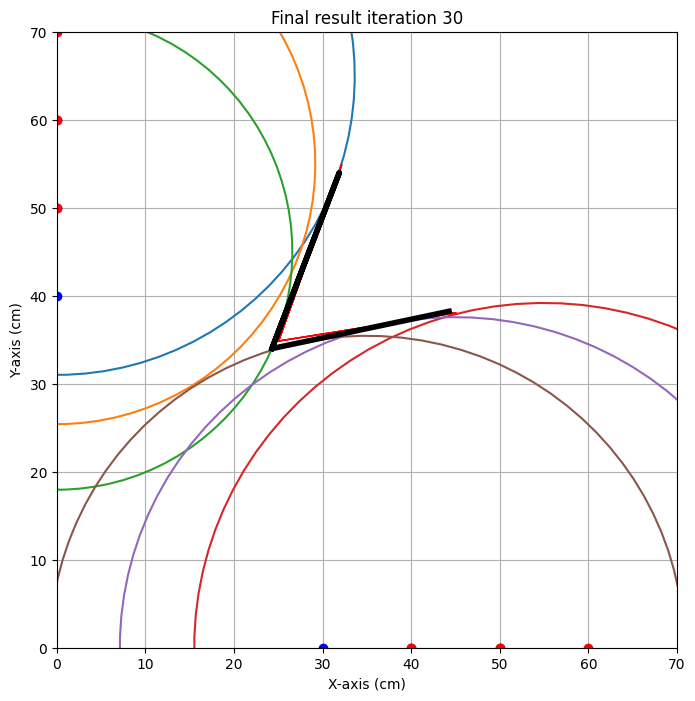

{'alpha': np.float64(11.955395932188505), 'alpha_eps': np.float64(2.844494827603601), 'beta': np.float64(20.847720250589187), 'beta_eps': np.float64(1.2492813483956944), 'x0': np.float64(24.275301806968617), 'x0_eps': np.float64(0.7460261951897422), 'y0': np.float64(33.995125818869894), 'y0_eps': np.float64(0.8534495206960173)}


In [7]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [8]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Elisabeth 
x0 target is : 26.5. Gevonden waarde: 28.2 cm met een standaardafwijking van 0.4 cm 
y0 target is : 34.5. Gevonden waarde: 34.2 cm met een standaardafwijking van 0.6 cm 
alpha target is : 13.0. Gevonden waarde: 13.0 graden met een standaardafwijking van 3.2 graad 
beta target is : 13.0. Gevonden waarde: -6.4 graden met een standaardafwijking van 1.6 graad 

Oscar 
x0 target is : 26.5. Gevonden waarde: 23.5 cm met een standaardafwijking van 0.6 cm 
y0 target is : 34.5. Gevonden waarde: 33.6 cm met een standaardafwijking van 0.6 cm 
alpha target is : 13.0. Gevonden waarde: 10.8 graden met een standaardafwijking van 2.2 graad 
beta target is : 13.0. Gevonden waarde: 21.4 graden met een standaardafwijking van 2.2 graad 

Lars 
x0 target is : 26.5. Gevonden waarde: 24.3 cm met een standaardafwijking van 0.7 cm 
y0 target is : 34.5. Gevonden waarde: 34.0 cm met een standaardafwijking van 0.9 cm 
alpha target is : 13.0. Gevonden waarde: 12.0 graden met een standaardafwijking van 2.

## Opdracht 8: Iteratie1+ 14:41
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

## Figuur: iteratie 1 ![Alt](Iteratie1.jpeg)
## Figuur: iteratie 2 ![Alt](Iteratie2.jpeg)
## Figuur: iteratie 3 ![Alt](iteratie3.jpeg)


## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  75.2
1  45   0  55   0  77.6
2  50   0  60   0  79.4
3  35   0  45   0  72.6
4  30   0  40   0  72.0
5   0  40   0  50  54.0
6   0  45   0  55  56.5
7   0  50   0  60  60.6
8   0  35   0  45  55.6
9   0  55   0  65  67.8


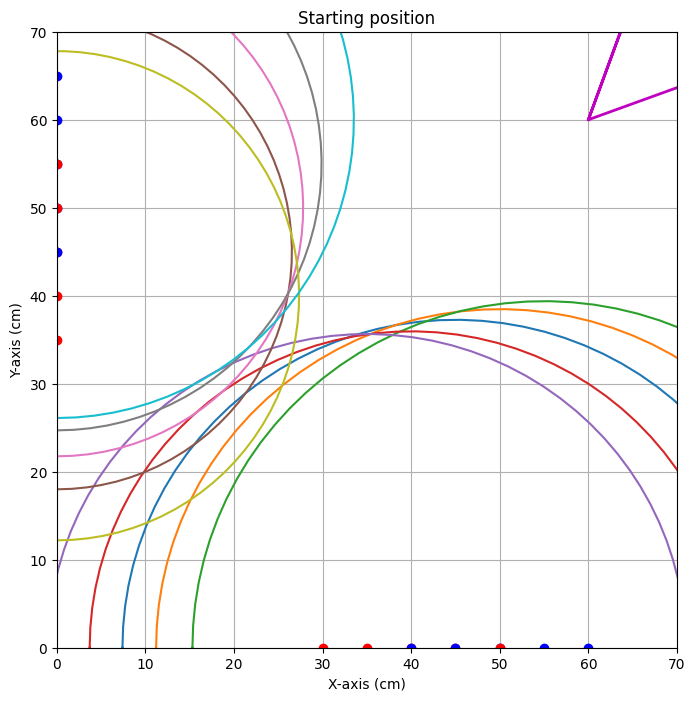


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=62.804


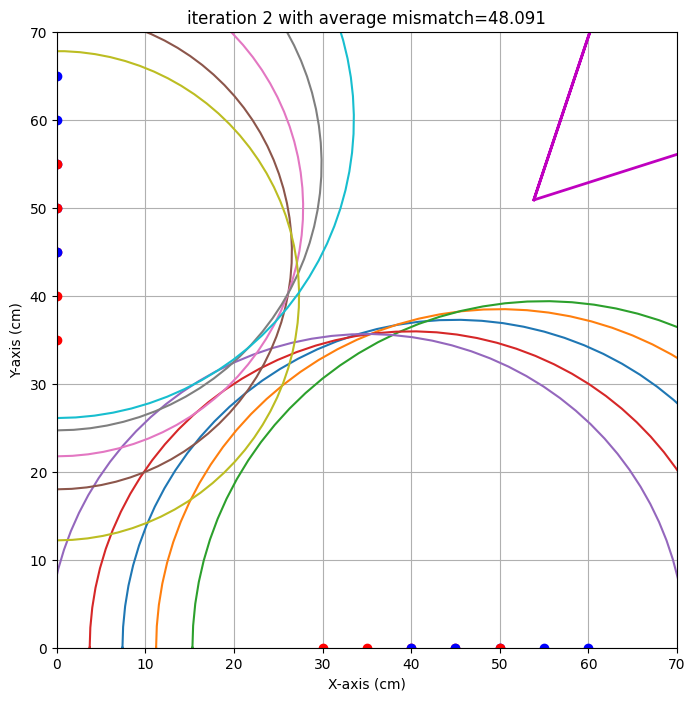

end iteration 2 with average mismatch=48.091


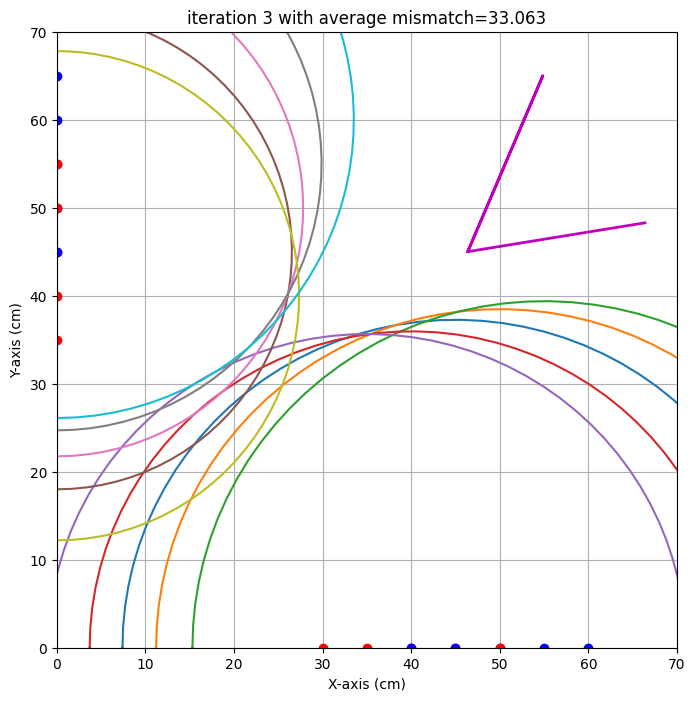

end iteration 3 with average mismatch=33.063


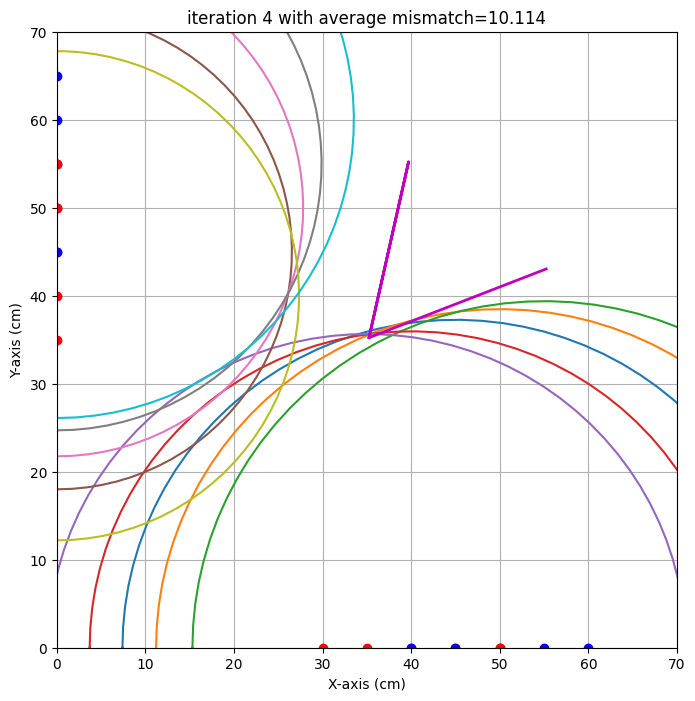

end iteration 4 with average mismatch=10.114


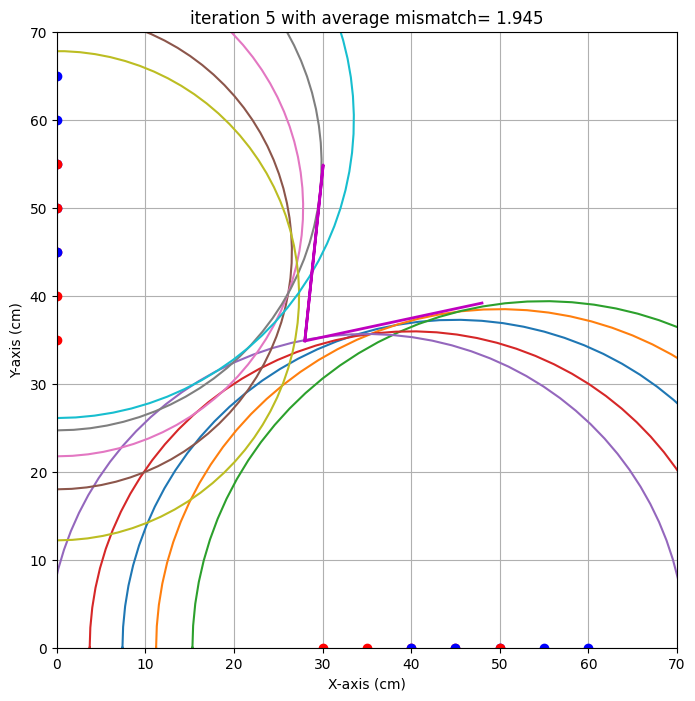

end iteration 5 with average mismatch= 1.945


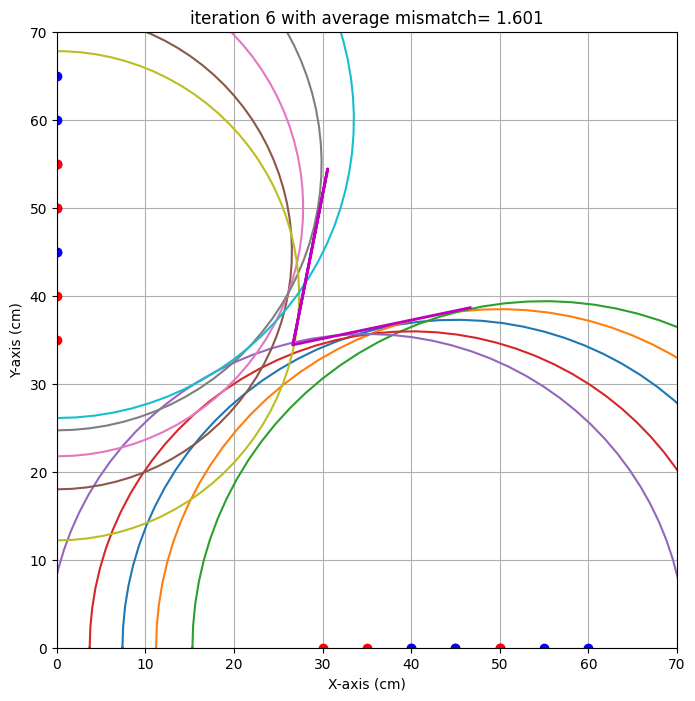

end iteration 6 with average mismatch= 1.601
end iteration 7 with average mismatch= 1.595
end iteration 8 with average mismatch= 1.594
end iteration 9 with average mismatch= 1.594
end iteration 10 with average mismatch= 1.594
end iteration 11 with average mismatch= 1.537
end iteration 12 with average mismatch= 1.523
end iteration 13 with average mismatch= 1.522
end iteration 14 with average mismatch= 1.522
end iteration 15 with average mismatch= 1.522
end iteration 16 with average mismatch= 1.522
end iteration 17 with average mismatch= 1.522
end iteration 18 with average mismatch= 1.522
end iteration 19 with average mismatch= 1.505
end iteration 20 with average mismatch= 1.504
end iteration 21 with average mismatch= 1.485
end iteration 22 with average mismatch= 1.480
end iteration 23 with average mismatch= 1.480
end iteration 24 with average mismatch= 1.480
end iteration 25 with average mismatch= 1.480
end iteration 26 with average mismatch= 1.480
end iteration 27 with average mismatch

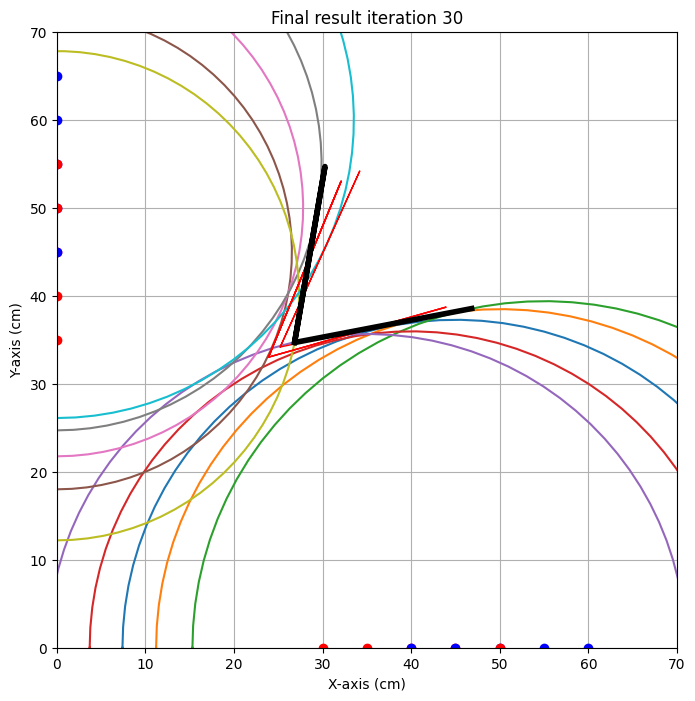

{'alpha': np.float64(10.933306865335933), 'alpha_eps': np.float64(4.894757116065364), 'beta': np.float64(9.745434880579333), 'beta_eps': np.float64(14.436022482295227), 'x0': np.float64(26.830019708551777), 'x0_eps': np.float64(2.9400223068480003), 'y0': np.float64(34.678421802283694), 'y0_eps': np.float64(1.6574209408280396)}
locatie 2
Running the imaging algorithm with the following data:
     xs    ys    xr    yr     R
0  50.0   0.0  65.0   0.0  93.5
1  52.5   0.0  67.5   0.0  95.1
2  55.0   0.0  70.0   0.0  97.0
3  47.5   0.0  62.5   0.0  91.0
4  45.0   0.0  60.0   0.0  90.3
5   0.0  50.0   0.0  65.0  67.8
6   0.0  52.5   0.0  67.5  68.1
7   0.0  55.0   0.0  70.0  70.7
8   0.0  47.5   0.0  62.5  68.0
9   0.0  45.0   0.0  60.0  67.1


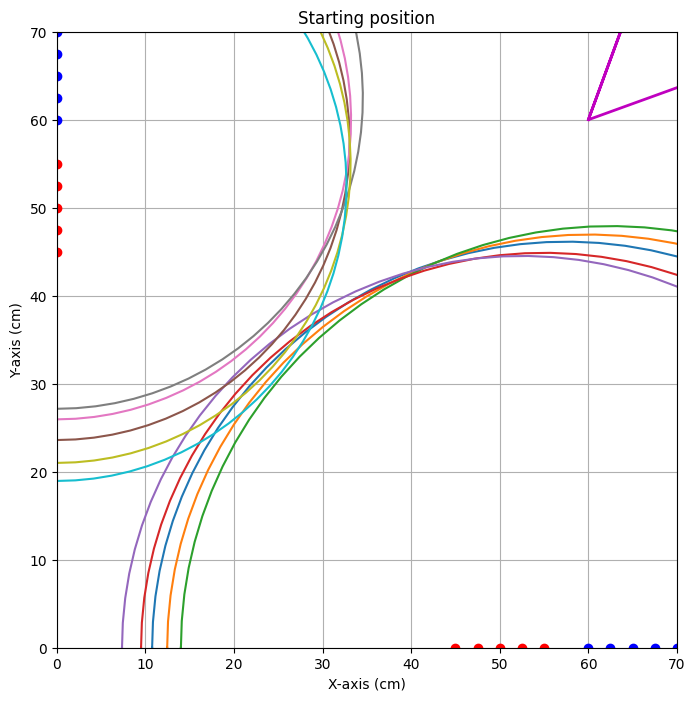


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.882


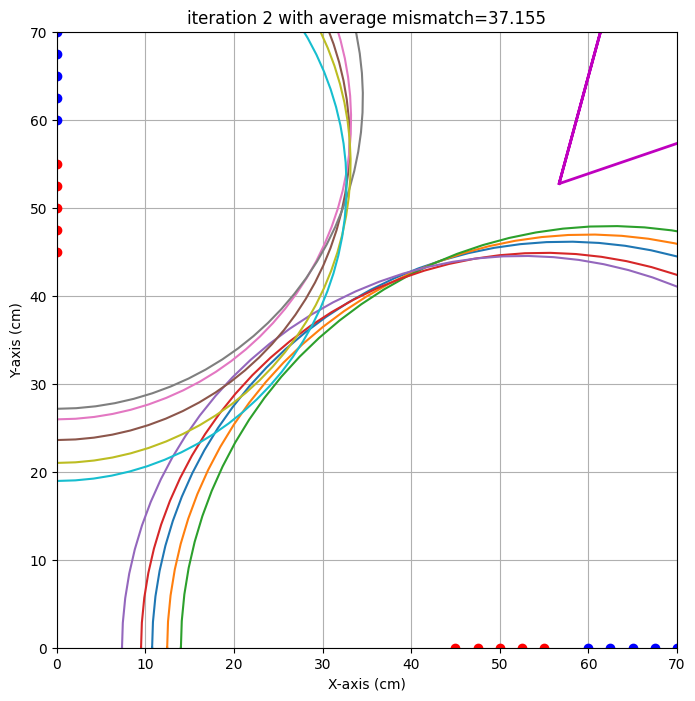

end iteration 2 with average mismatch=37.155


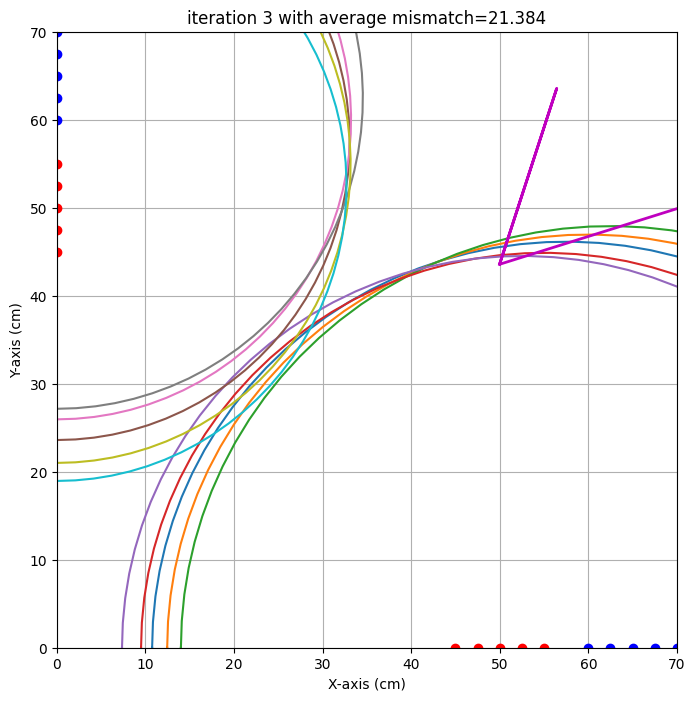

end iteration 3 with average mismatch=21.384


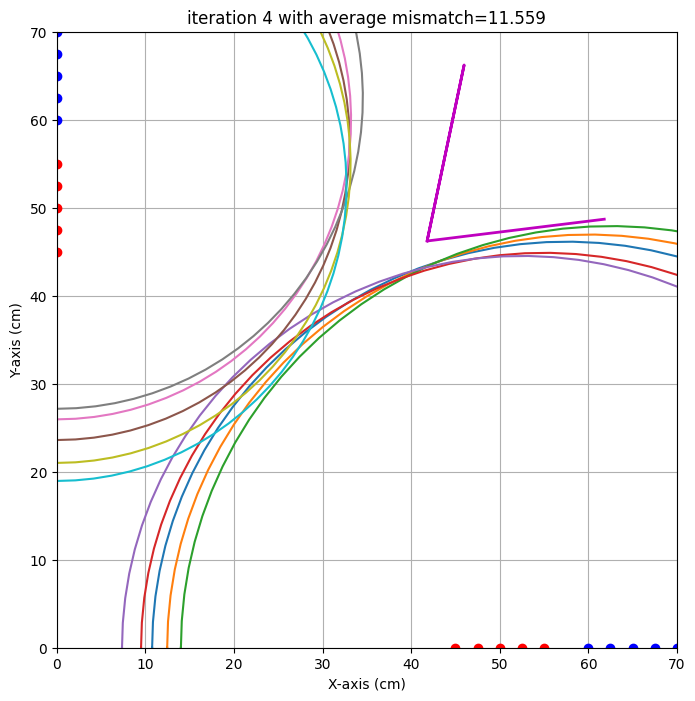

end iteration 4 with average mismatch=11.559


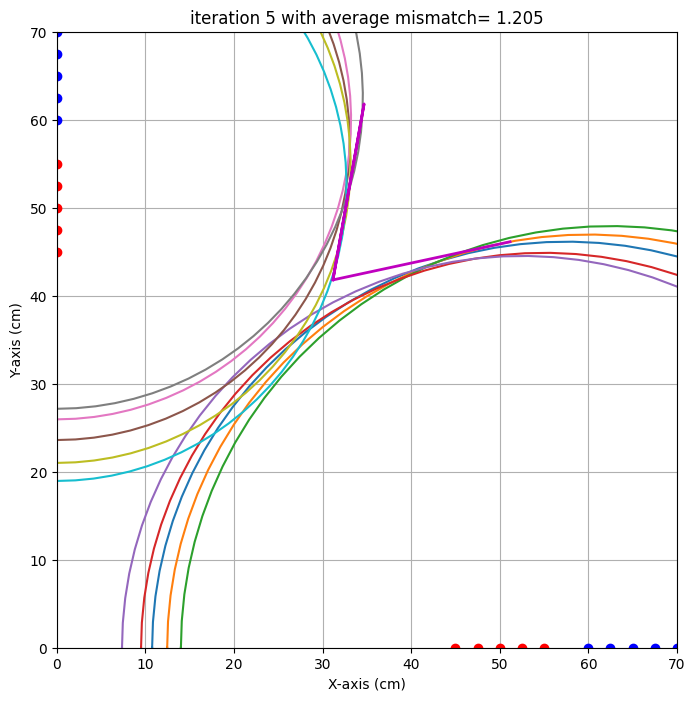

end iteration 5 with average mismatch= 1.205


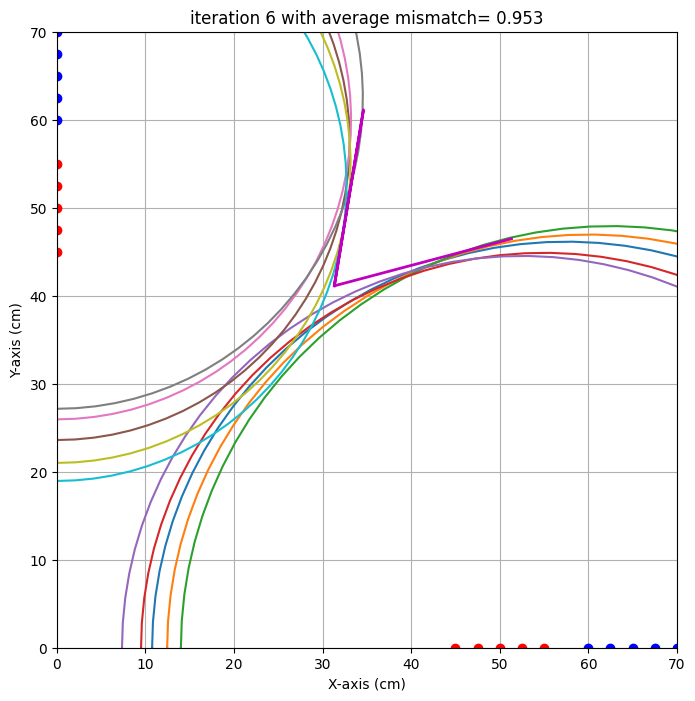

end iteration 6 with average mismatch= 0.953
end iteration 7 with average mismatch= 0.895
end iteration 8 with average mismatch= 0.885


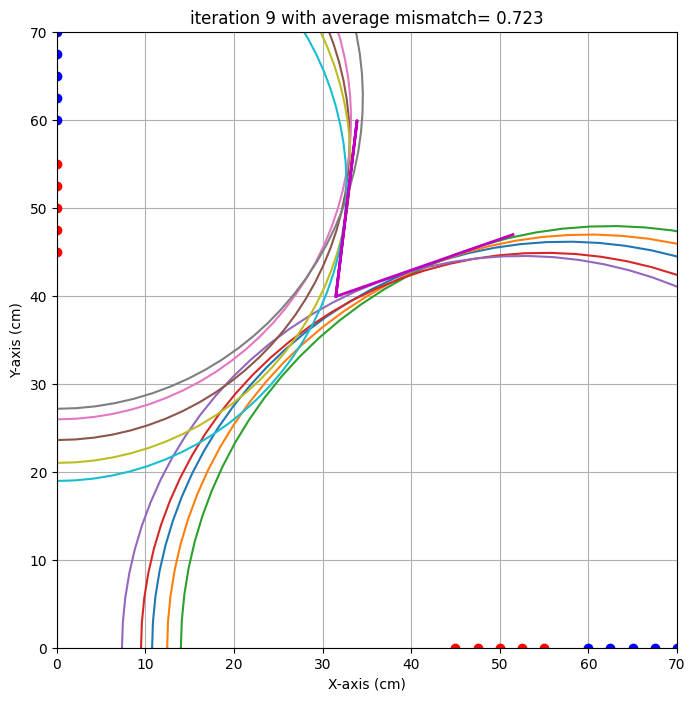

end iteration 9 with average mismatch= 0.723
end iteration 10 with average mismatch= 0.723
end iteration 11 with average mismatch= 0.706
end iteration 12 with average mismatch= 0.700
end iteration 13 with average mismatch= 0.696
end iteration 14 with average mismatch= 0.695
end iteration 15 with average mismatch= 0.653
end iteration 16 with average mismatch= 0.626
end iteration 17 with average mismatch= 0.618
end iteration 18 with average mismatch= 0.607
end iteration 19 with average mismatch= 0.605
end iteration 20 with average mismatch= 0.605
end iteration 21 with average mismatch= 0.605
end iteration 22 with average mismatch= 0.584
end iteration 23 with average mismatch= 0.583
end iteration 24 with average mismatch= 0.583
end iteration 25 with average mismatch= 0.583
end iteration 26 with average mismatch= 0.583
end iteration 27 with average mismatch= 0.583
end iteration 28 with average mismatch= 0.583
end iteration 29 with average mismatch= 0.583
Last iteration, also determine unce

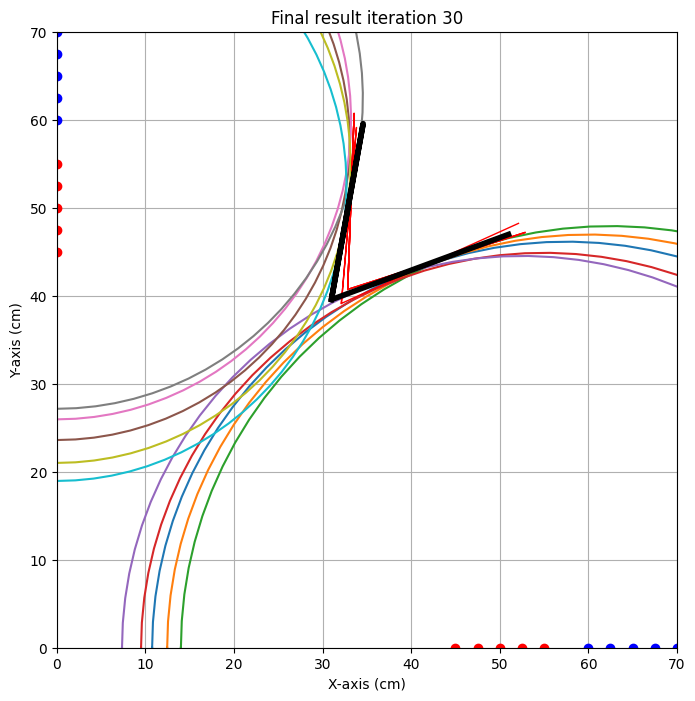

{'alpha': np.float64(20.33152962460051), 'alpha_eps': np.float64(4.138369333116952), 'beta': np.float64(10.174934670727364), 'beta_eps': np.float64(8.100040950947646), 'x0': np.float64(30.988031357464084), 'x0_eps': np.float64(1.8457868720695352), 'y0': np.float64(39.55756437784839), 'y0_eps': np.float64(1.1590492257340514)}
locatie 3
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  65   0  92.4
1  55   0  70   0  98.0
2  45   0  60   0  89.6
3   0  50   0  65  67.3
4   0  55   0  70  69.6
5   0  45   0  60  65.5


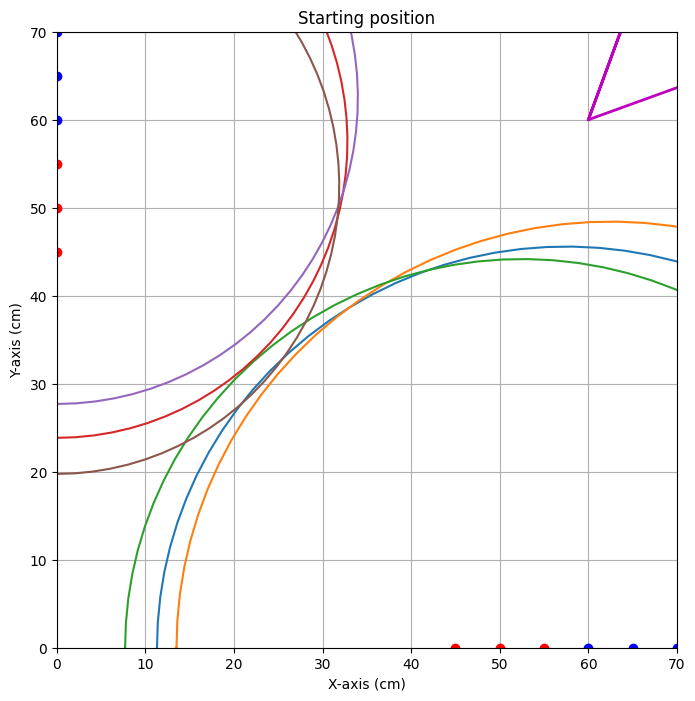


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=46.406


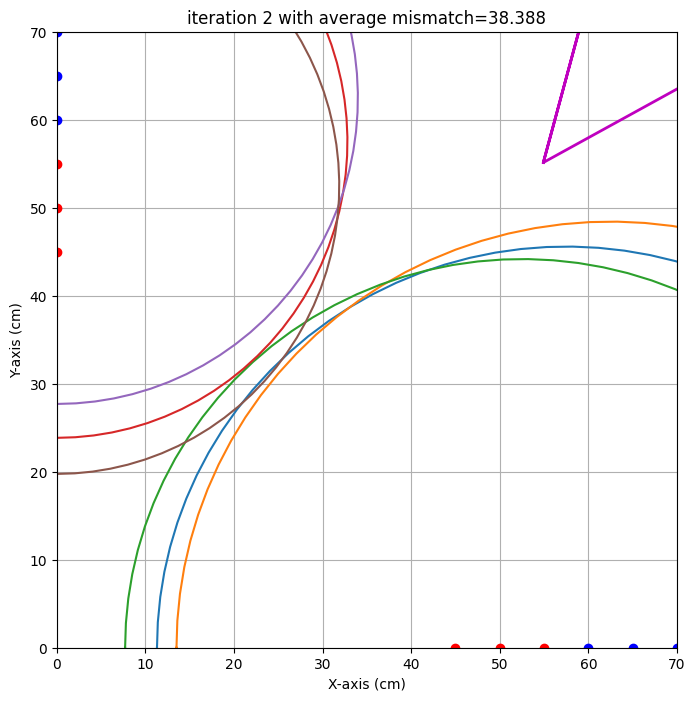

end iteration 2 with average mismatch=38.388


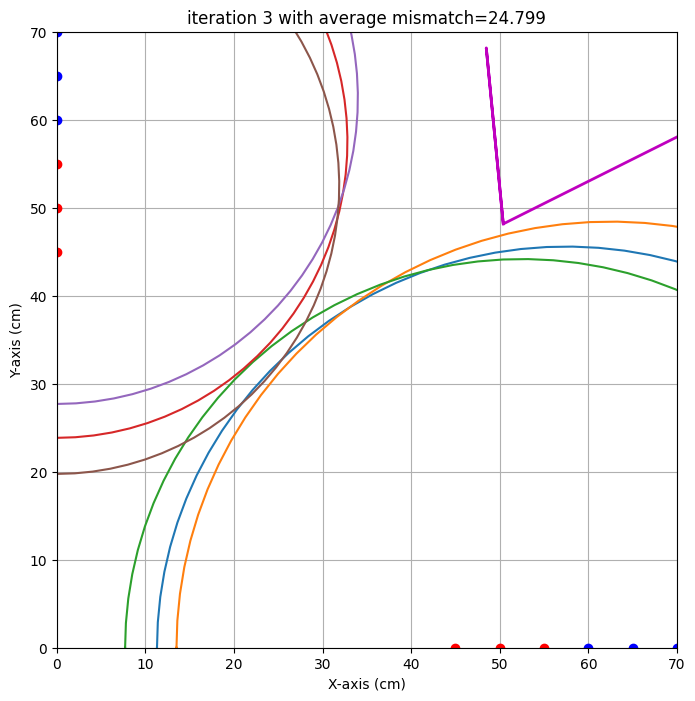

end iteration 3 with average mismatch=24.799


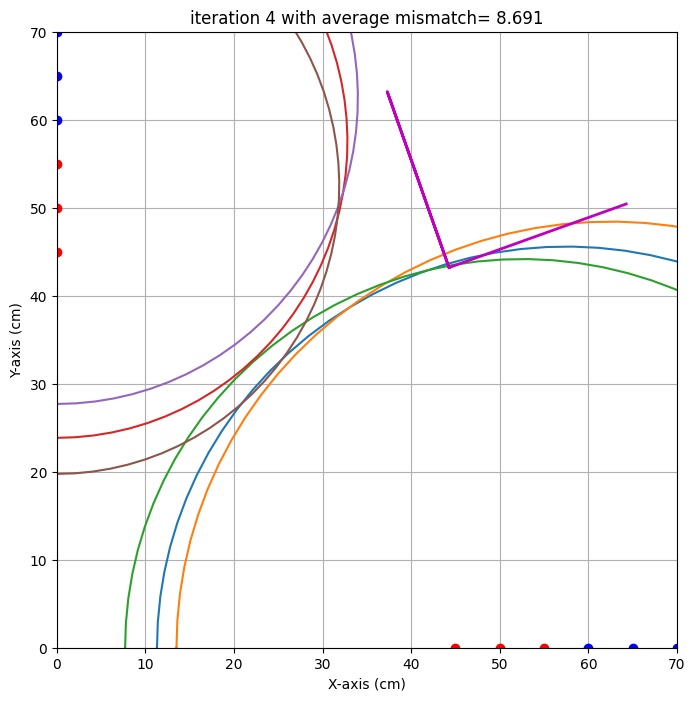

end iteration 4 with average mismatch= 8.691


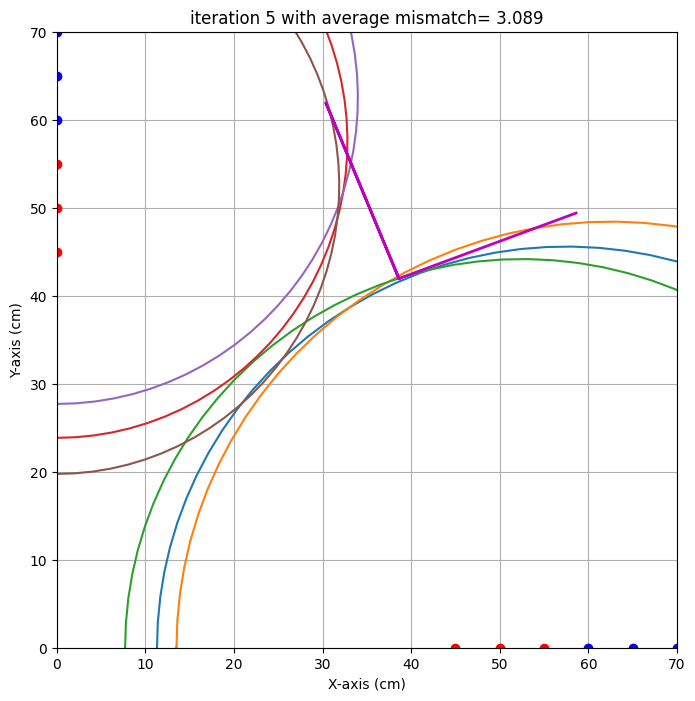

end iteration 5 with average mismatch= 3.089
end iteration 6 with average mismatch= 3.089
end iteration 7 with average mismatch= 3.050
end iteration 8 with average mismatch= 2.901
end iteration 9 with average mismatch= 2.901
end iteration 10 with average mismatch= 2.901


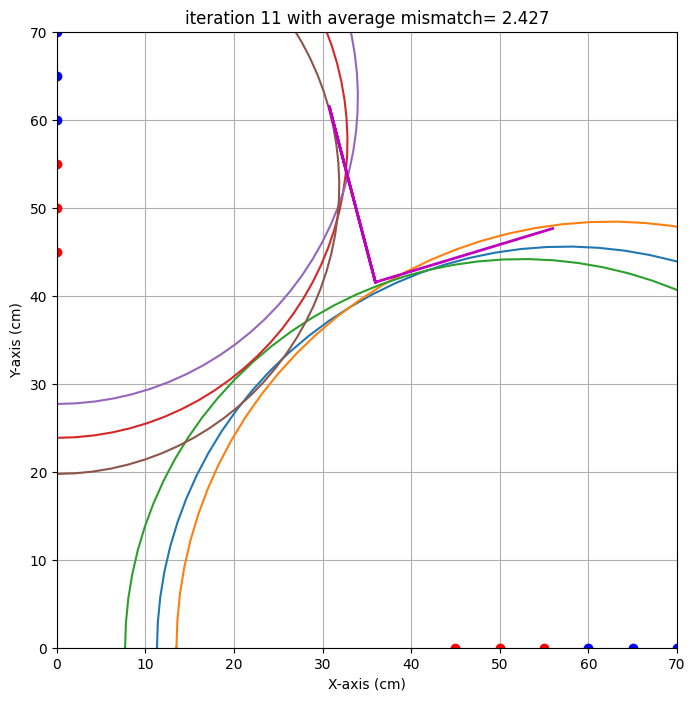

end iteration 11 with average mismatch= 2.427


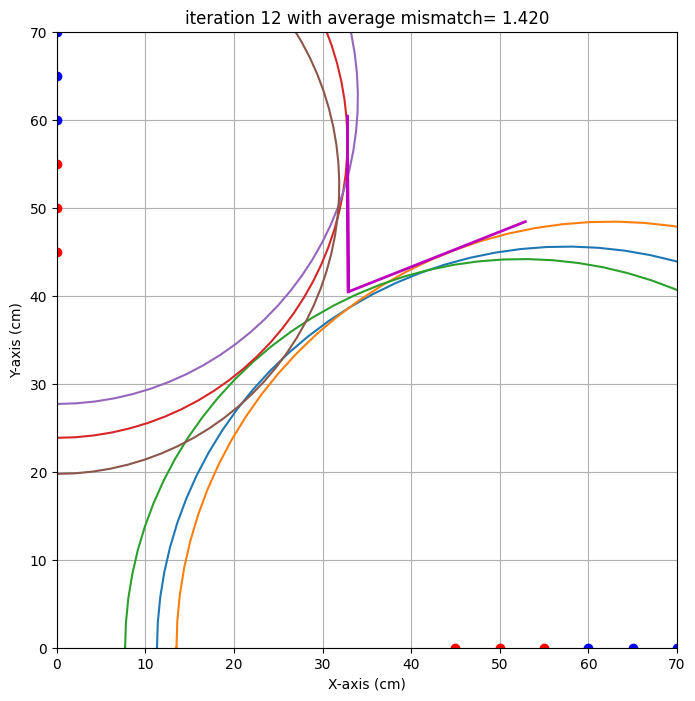

end iteration 12 with average mismatch= 1.420


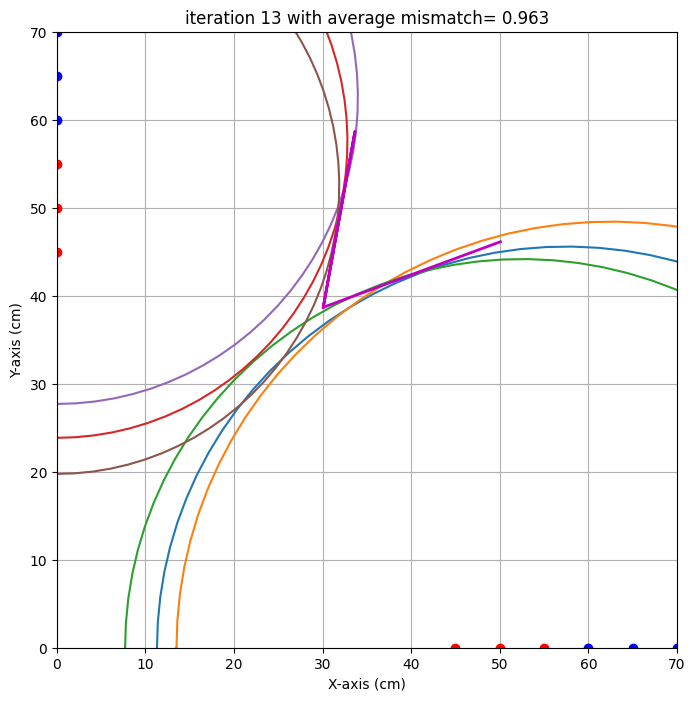

end iteration 13 with average mismatch= 0.963


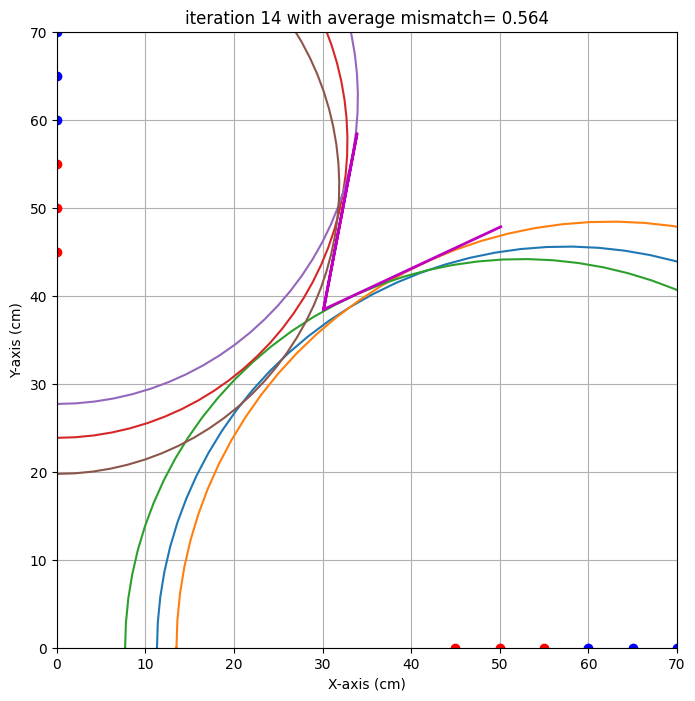

end iteration 14 with average mismatch= 0.564
end iteration 15 with average mismatch= 0.517
end iteration 16 with average mismatch= 0.516
end iteration 17 with average mismatch= 0.515
end iteration 18 with average mismatch= 0.515
end iteration 19 with average mismatch= 0.515
end iteration 20 with average mismatch= 0.515
end iteration 21 with average mismatch= 0.515
end iteration 22 with average mismatch= 0.515
end iteration 23 with average mismatch= 0.515
end iteration 24 with average mismatch= 0.515
end iteration 25 with average mismatch= 0.515
end iteration 26 with average mismatch= 0.515
end iteration 27 with average mismatch= 0.515
end iteration 28 with average mismatch= 0.515
end iteration 29 with average mismatch= 0.515
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.515
###############################################################################
end of iteration  30
Best alp

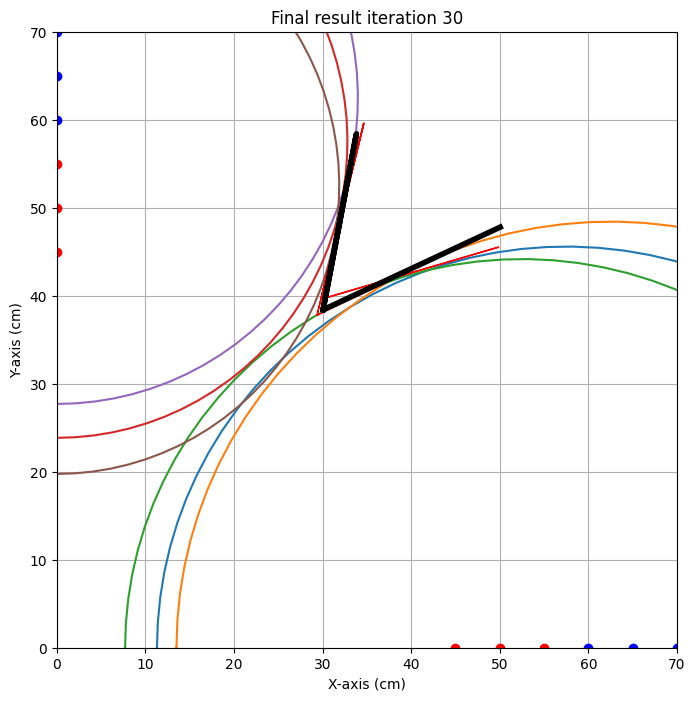

{'alpha': np.float64(25.159522264175976), 'alpha_eps': np.float64(8.700566853051388), 'beta': np.float64(10.674038863309221), 'beta_eps': np.float64(2.93591807928723), 'x0': np.float64(30.048557243642325), 'x0_eps': np.float64(0.6800370689471542), 'y0': np.float64(38.39974657613131), 'y0_eps': np.float64(1.1950999596933087)}
locatie 4
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  35   0  50   0  81.1
1  30   0  45   0  78.4
2  25   0  40   0  78.0
3   0  50   0  65  51.6
4   0  55   0  70  54.4
5   0  45   0  60  50.6


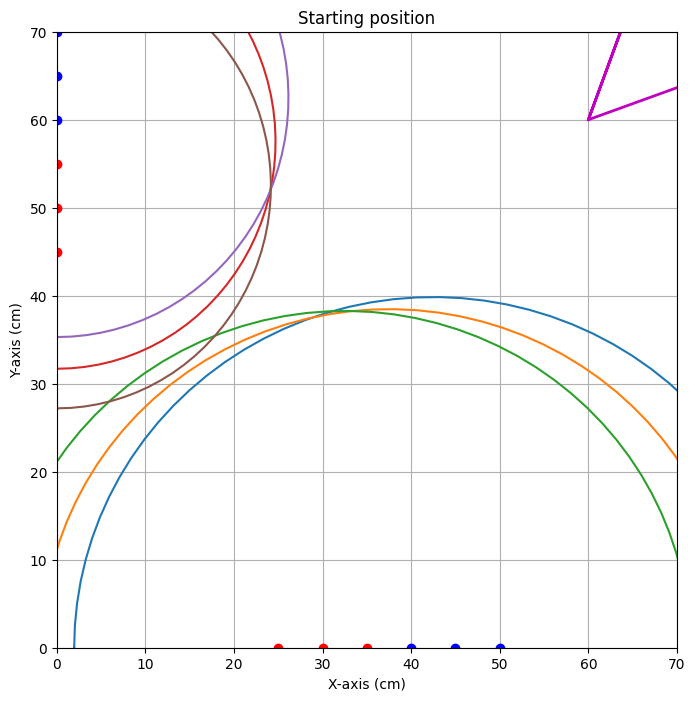


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=65.029


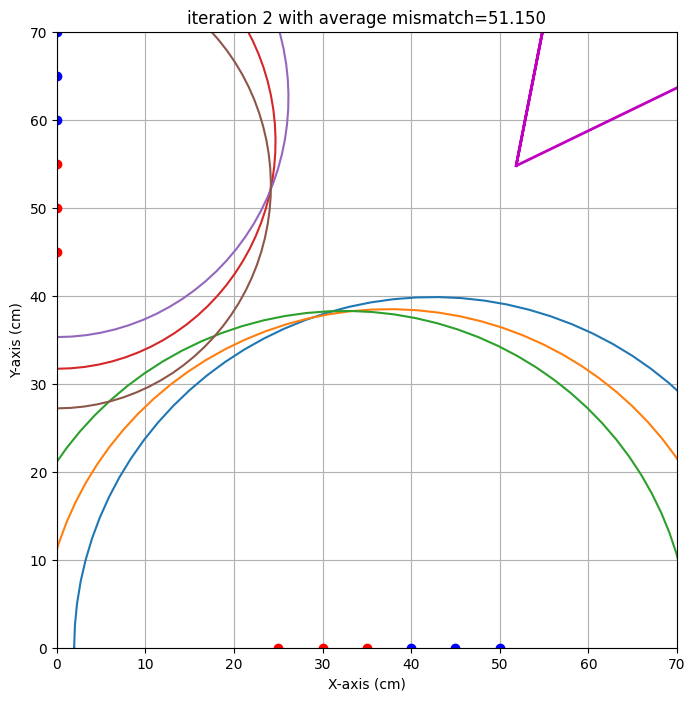

end iteration 2 with average mismatch=51.150


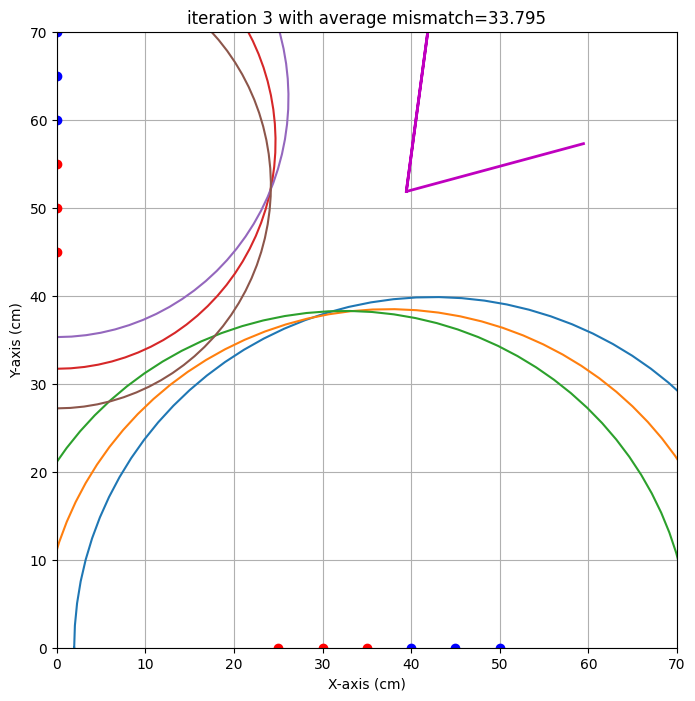

end iteration 3 with average mismatch=33.795


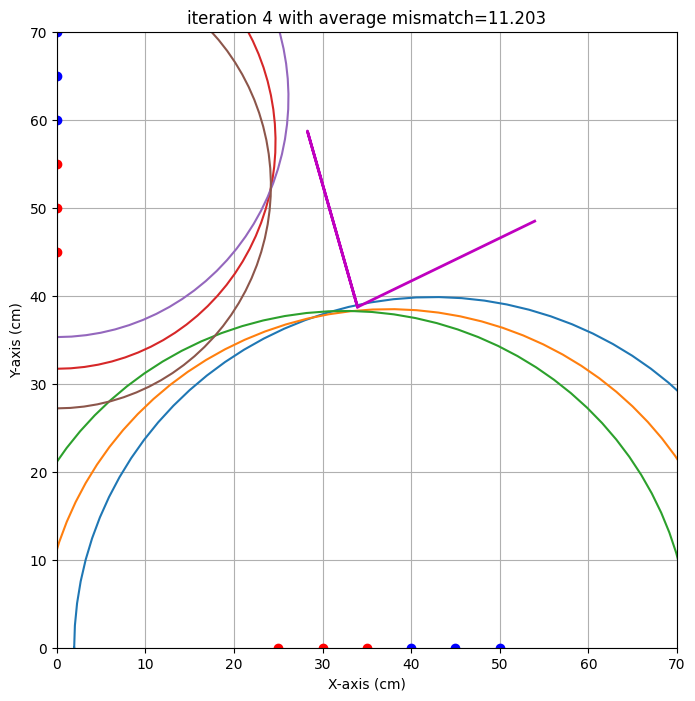

end iteration 4 with average mismatch=11.203


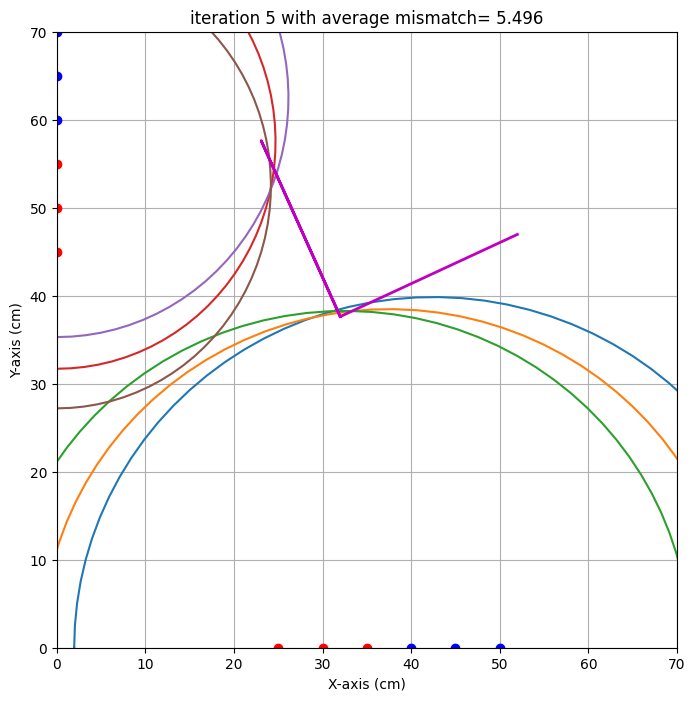

end iteration 5 with average mismatch= 5.496


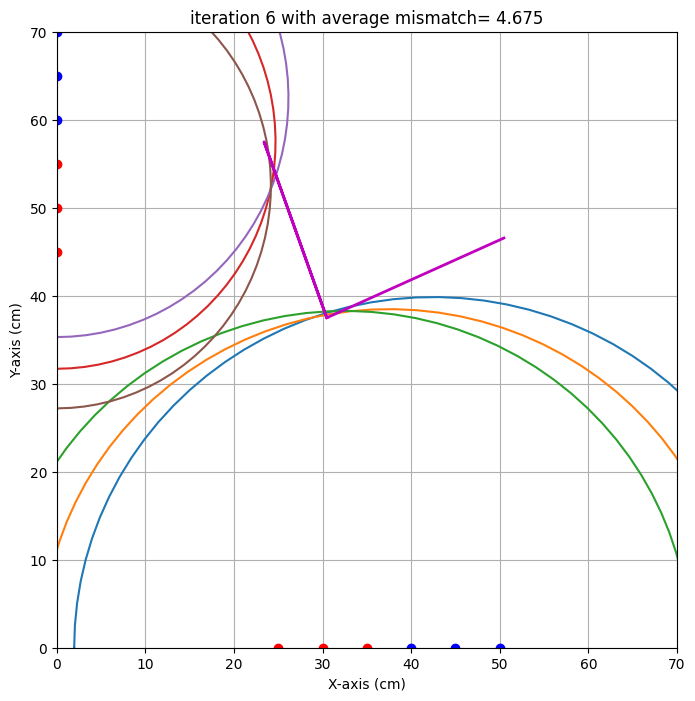

end iteration 6 with average mismatch= 4.675


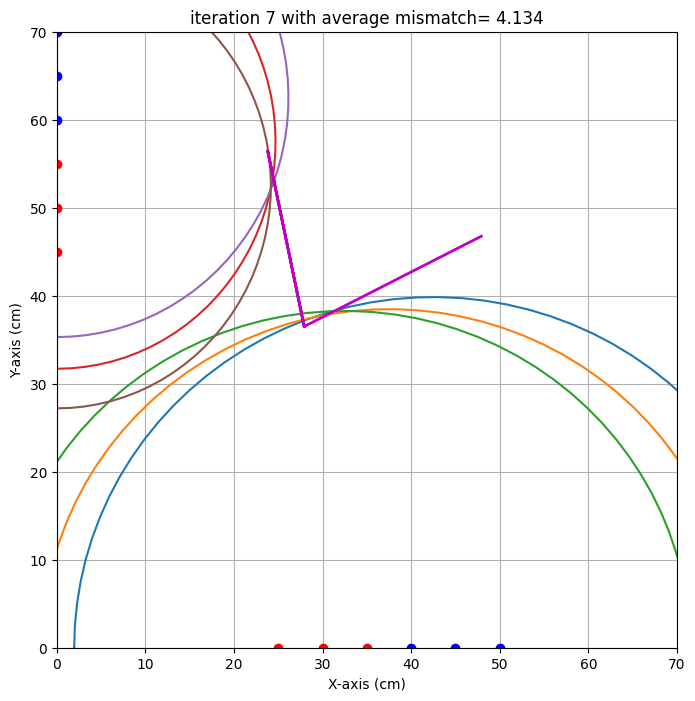

end iteration 7 with average mismatch= 4.134


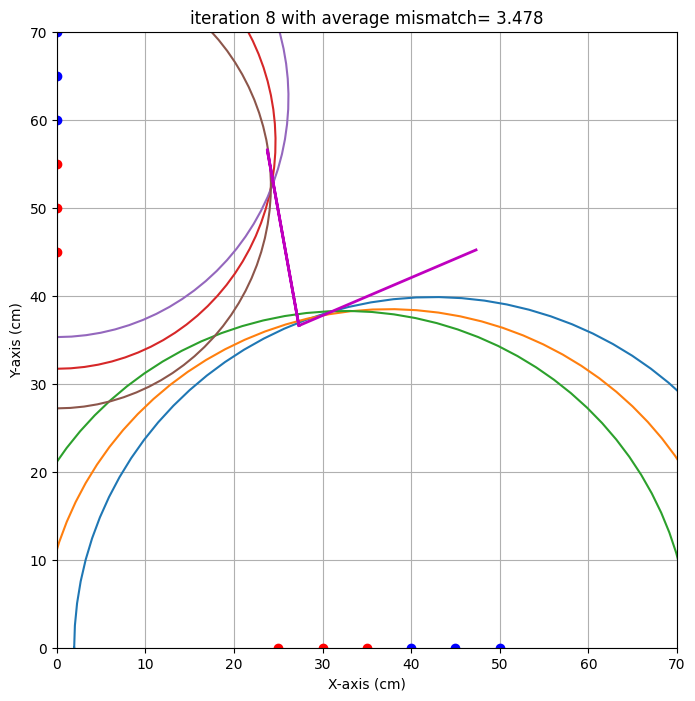

end iteration 8 with average mismatch= 3.478


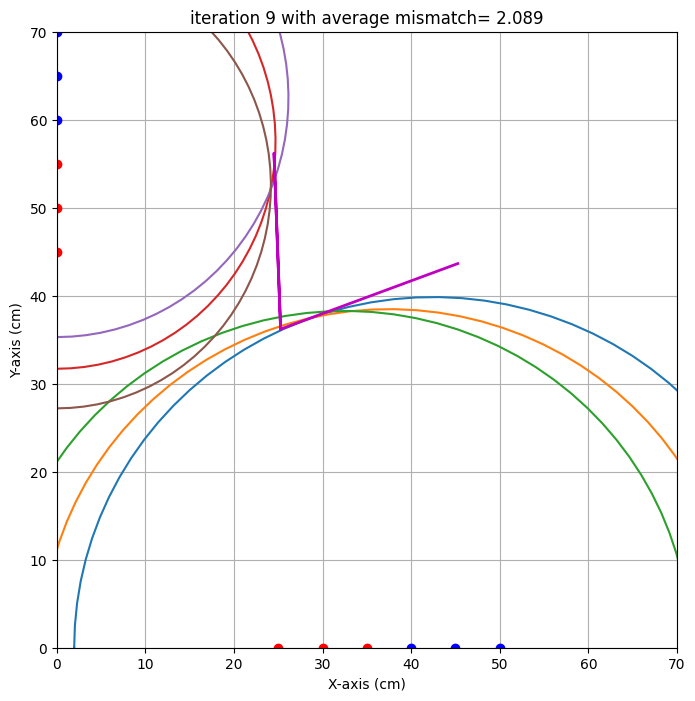

end iteration 9 with average mismatch= 2.089


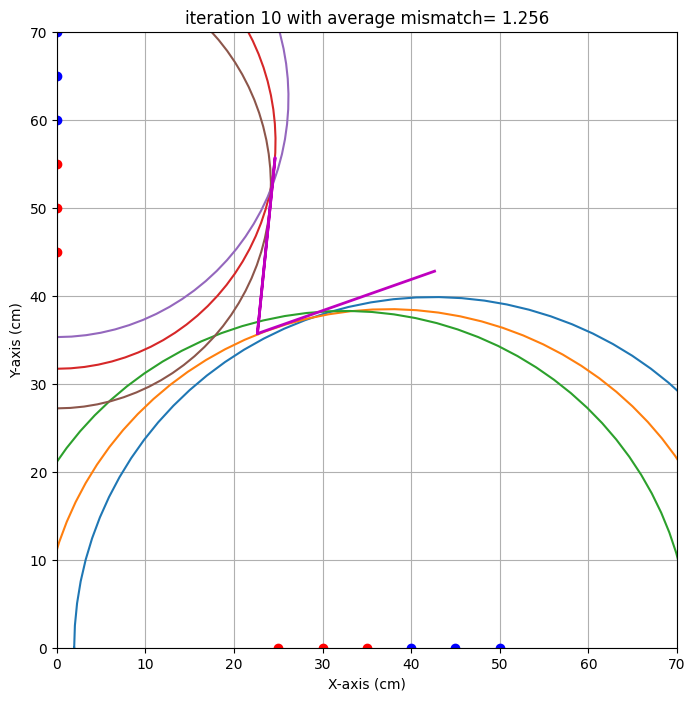

end iteration 10 with average mismatch= 1.256


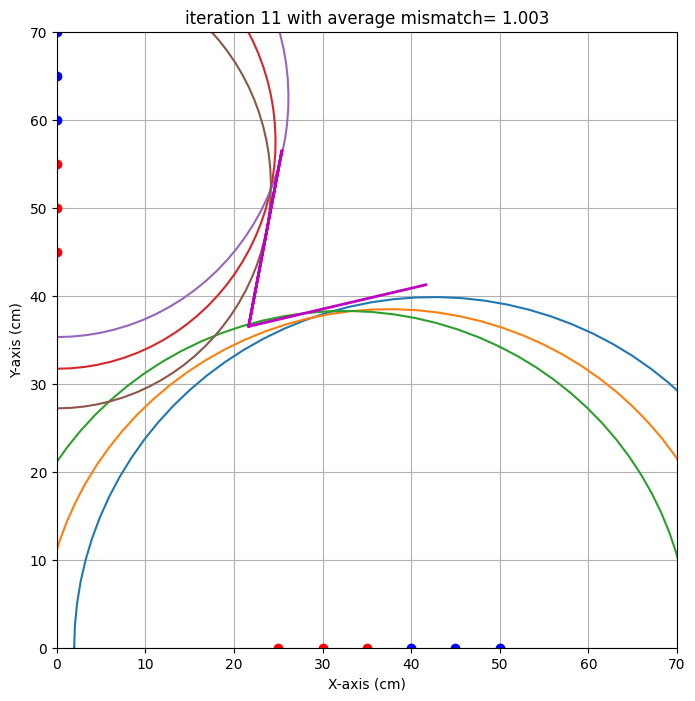

end iteration 11 with average mismatch= 1.003
end iteration 12 with average mismatch= 0.927


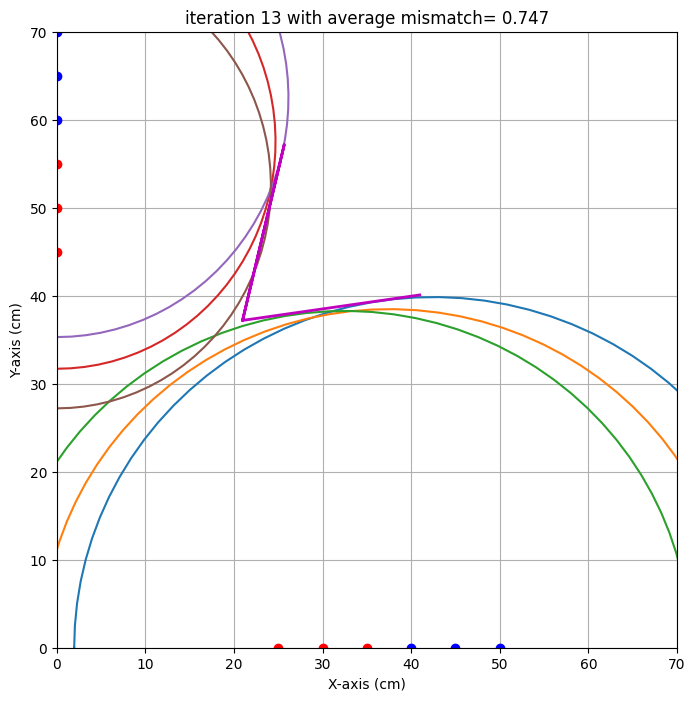

end iteration 13 with average mismatch= 0.747


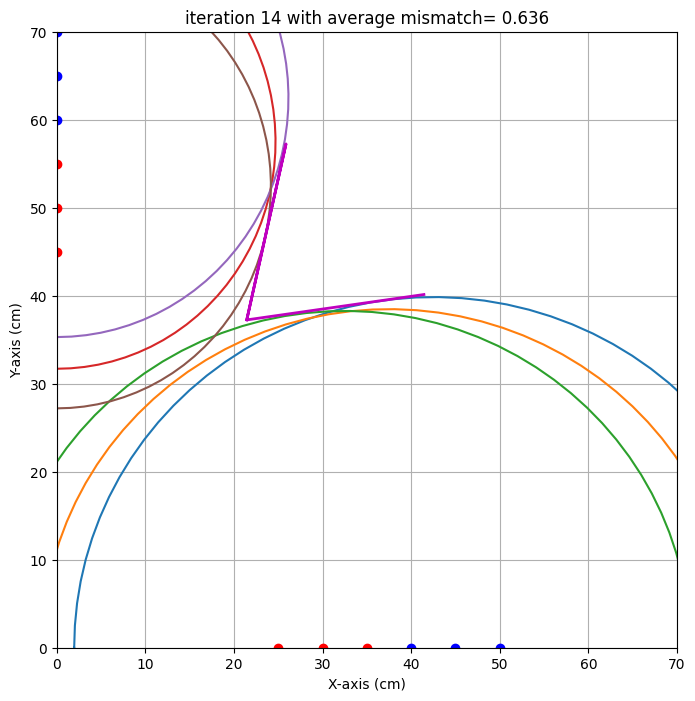

end iteration 14 with average mismatch= 0.636
end iteration 15 with average mismatch= 0.618
end iteration 16 with average mismatch= 0.614
end iteration 17 with average mismatch= 0.614
end iteration 18 with average mismatch= 0.614
end iteration 19 with average mismatch= 0.614
end iteration 20 with average mismatch= 0.614
end iteration 21 with average mismatch= 0.614
end iteration 22 with average mismatch= 0.614
end iteration 23 with average mismatch= 0.614
end iteration 24 with average mismatch= 0.614
end iteration 25 with average mismatch= 0.614
end iteration 26 with average mismatch= 0.614
end iteration 27 with average mismatch= 0.614
end iteration 28 with average mismatch= 0.614
end iteration 29 with average mismatch= 0.614
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.614
###############################################################################
end of iteration  30
Best alp

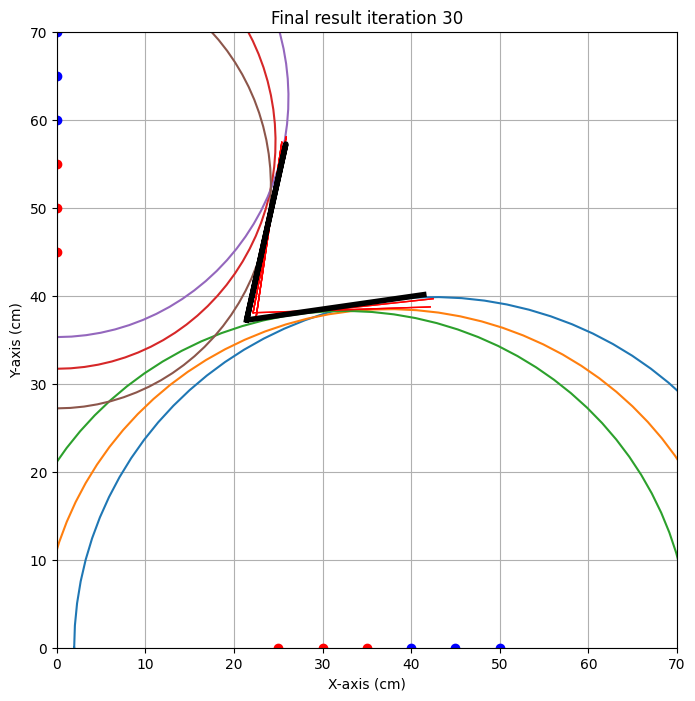

{'alpha': np.float64(8.199393748806486), 'alpha_eps': np.float64(6.298390679043831), 'beta': np.float64(12.484635896404717), 'beta_eps': np.float64(4.183365955013697), 'x0': np.float64(21.41897197816404), 'x0_eps': np.float64(1.0605558557304064), 'y0': np.float64(37.23672499429454), 'y0_eps': np.float64(0.8266688215319817)}
locatie 1 
x0 target is : 26.5. Gevonden waarde: 26.8 cm met een standaardafwijking van 2.9 cm 
y0 target is : 34.5. Gevonden waarde: 34.7 cm met een standaardafwijking van 1.7 cm 
alpha target is : 13.0. Gevonden waarde: 10.9 graden met een standaardafwijking van 4.9 graad 
beta target is : 13.0. Gevonden waarde: 9.7 graden met een standaardafwijking van 14.4 graad 

locatie 2 
x0 target is : 29.8. Gevonden waarde: 31.0 cm met een standaardafwijking van 1.8 cm 
y0 target is : 39.0. Gevonden waarde: 39.6 cm met een standaardafwijking van 1.2 cm 
alpha target is : 32.0. Gevonden waarde: 20.3 graden met een standaardafwijking van 4.1 graad 
beta target is : 15.0. Gevo

In [9]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 26.5, 
                    'y0': 34.5, 
                    'alpha' : 13,
                    'beta' : 13,},
            'locatie 2':{'x0': 29.8,
                    'y0': 39 ,
                    'alpha' : 32,
                    'beta' : 15,},
            'locatie 3':{'x0': 29.8,
                    'y0': 39 ,
                    'alpha' : 32,
                    'beta' : 15,},
            'locatie 4':{'x0': 20.5,
                    'y0': 42,
                    'alpha' : -13,
                    'beta' : 17,
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,30,0,ongeldig],
    [40,0,50,0,75.2],
    [45,0,55,0,77.6],
    [50,0,60,0,79.4],
    [35,0,45,0,72.6],
    [30,0,40,0,72],
    #[0,20,0,30,ongeldig],
    [0,40,0,50,54],
    [0,45,0,55,56.5],
    [0,50,0,60,60.6],
    [0,35,0,45,55.6],
    #[0,30,0,40,ongeldig],
    [0,55,0,65,67.8],
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   # [35,0,50,0,ongeldig],
    [50,0,65,0,93.5],
    [52.5,0,67.5,0,95.1],
    [55,0,70,0,97],
    [47.5,0,62.5,0,91],
    [45,0,60,0,90.3],
    #[0,35,0,50,ongeldig],
    [0,50,0,65,67.8],
    [0,52.5,0,67.5,68.1],
    [0,55,0,70,70.7],
    [0,47.5,0,62.5,68],
    [0,45,0,60,67.1],
    ]),
           'locatie 3' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   # [35,0,50,0,ongeldig],
    [50,0,65,0,92.4],
    [55,0,70,0,98],
    [45,0,60,0,89.6],
    #[0,35,0,50,ongeldig],
    [0,50,0,65,67.3],
    [0,55,0,70,69.6],
    [0,45,0,60,65.5],
    ]),
               'locatie 4' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [35,0,50,0,81.1],
    [30,0,45,0,78.4],
    #[40,0,55,0,ongeldig],
    [25,0,40,0,78],
    #[0,35,0,50,ongeldig],
    [0,50,0,65,51.6],
    [0,55,0,70,54.4],
    [0,45,0,60,50.6],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  35   0  50   0  68.3
1  40   0  55   0  70.0
2  45   0  60   0  71.9
3   0  35   0  50  55.9
4   0  40   0  55  54.1
5   0  30   0  45  58.4


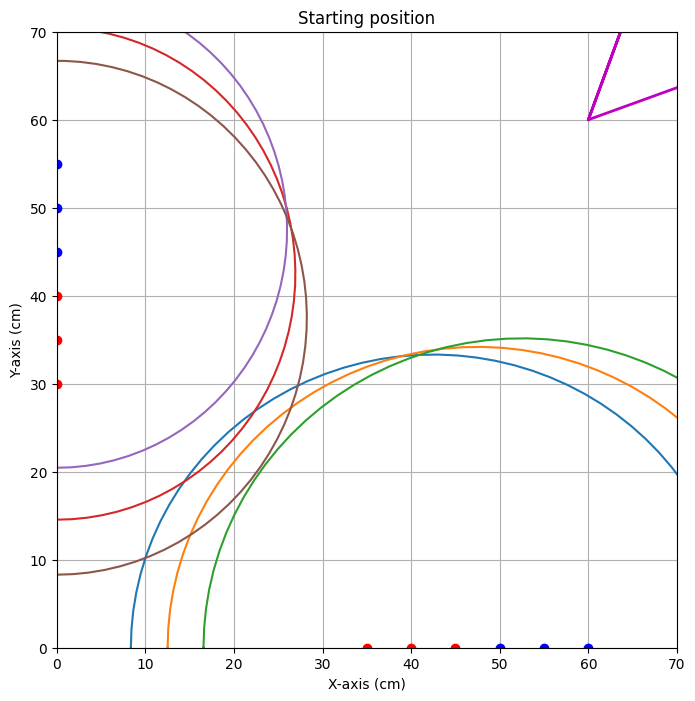


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.392


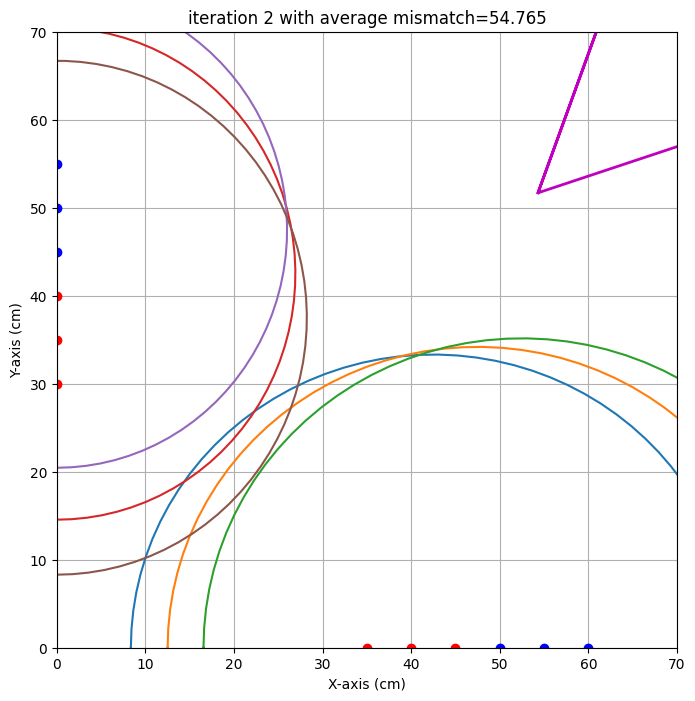

end iteration 2 with average mismatch=54.765


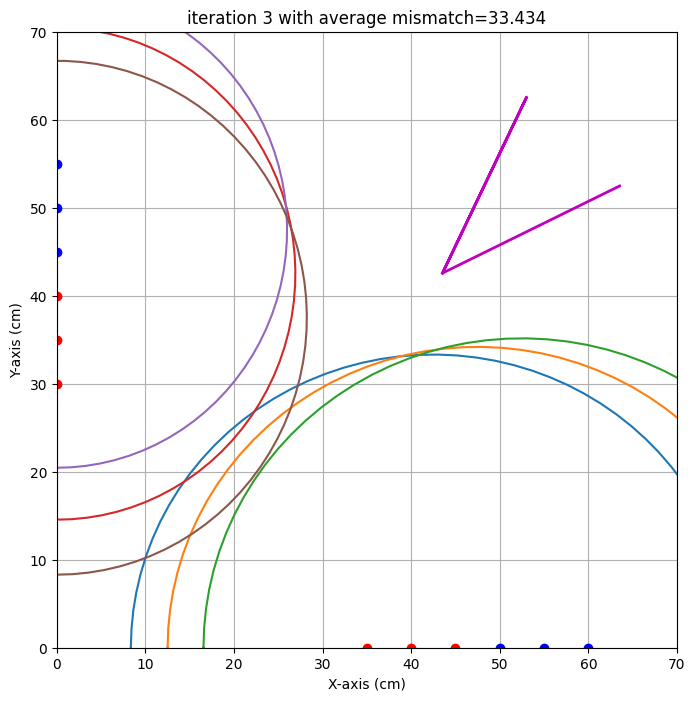

end iteration 3 with average mismatch=33.434


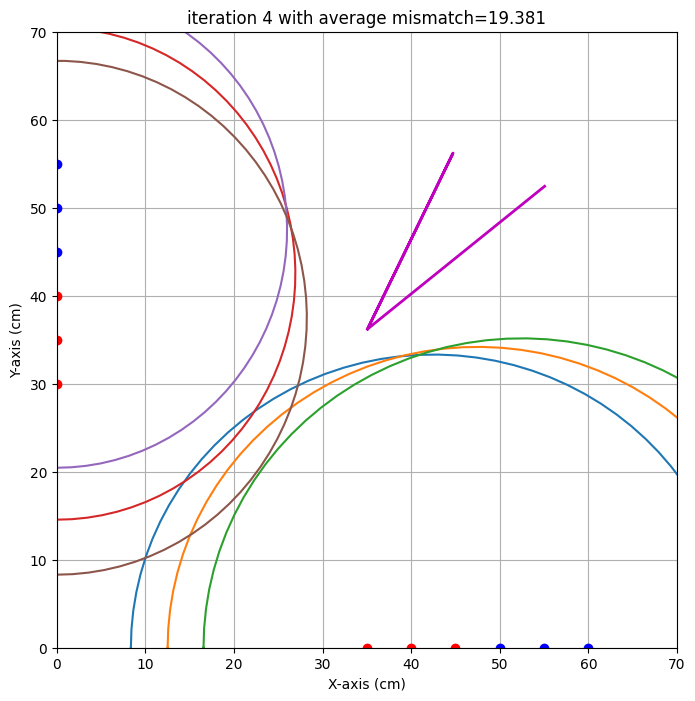

end iteration 4 with average mismatch=19.381


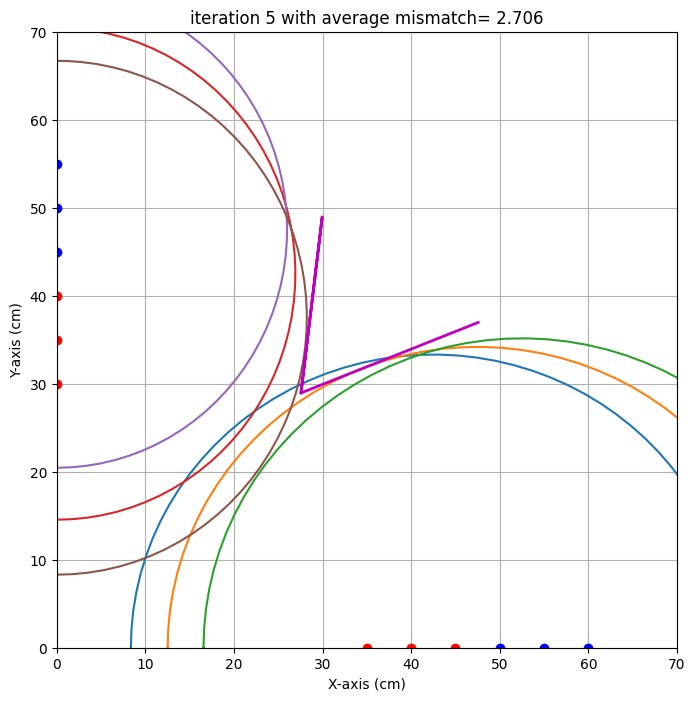

end iteration 5 with average mismatch= 2.706


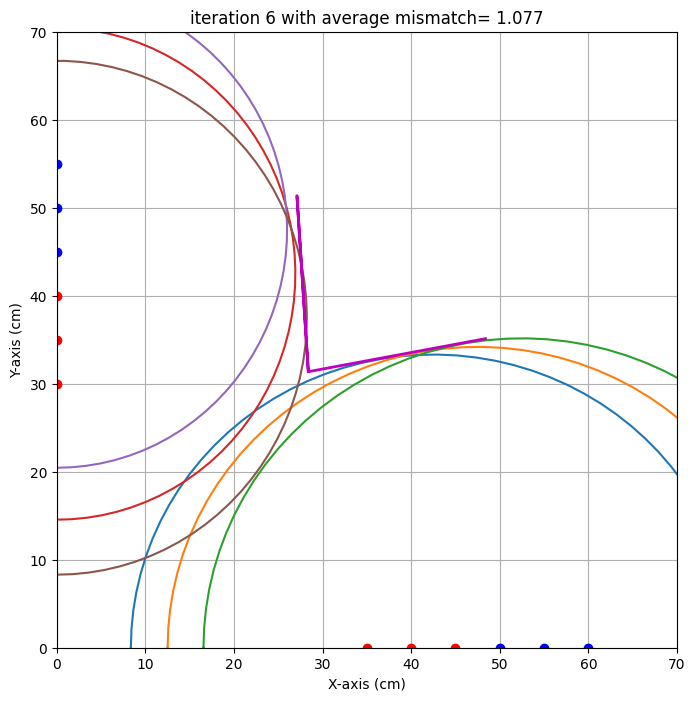

end iteration 6 with average mismatch= 1.077
end iteration 7 with average mismatch= 1.012


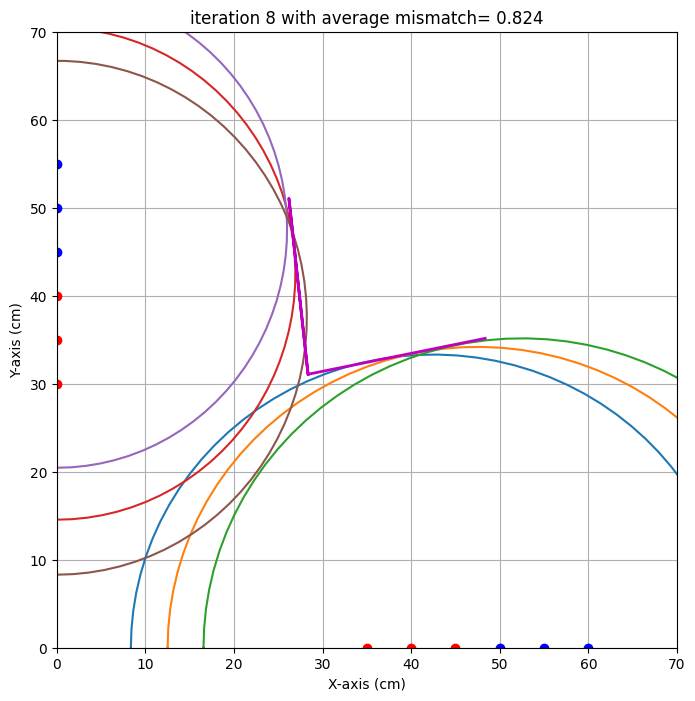

end iteration 8 with average mismatch= 0.824
end iteration 9 with average mismatch= 0.815
end iteration 10 with average mismatch= 0.744
end iteration 11 with average mismatch= 0.729
end iteration 12 with average mismatch= 0.726
end iteration 13 with average mismatch= 0.724
end iteration 14 with average mismatch= 0.724
end iteration 15 with average mismatch= 0.724
end iteration 16 with average mismatch= 0.724
end iteration 17 with average mismatch= 0.724
end iteration 18 with average mismatch= 0.724
end iteration 19 with average mismatch= 0.724
end iteration 20 with average mismatch= 0.724
end iteration 21 with average mismatch= 0.724
end iteration 22 with average mismatch= 0.724
end iteration 23 with average mismatch= 0.724
end iteration 24 with average mismatch= 0.724
end iteration 25 with average mismatch= 0.724
end iteration 26 with average mismatch= 0.724
end iteration 27 with average mismatch= 0.724
end iteration 28 with average mismatch= 0.724
end iteration 29 with average mismat

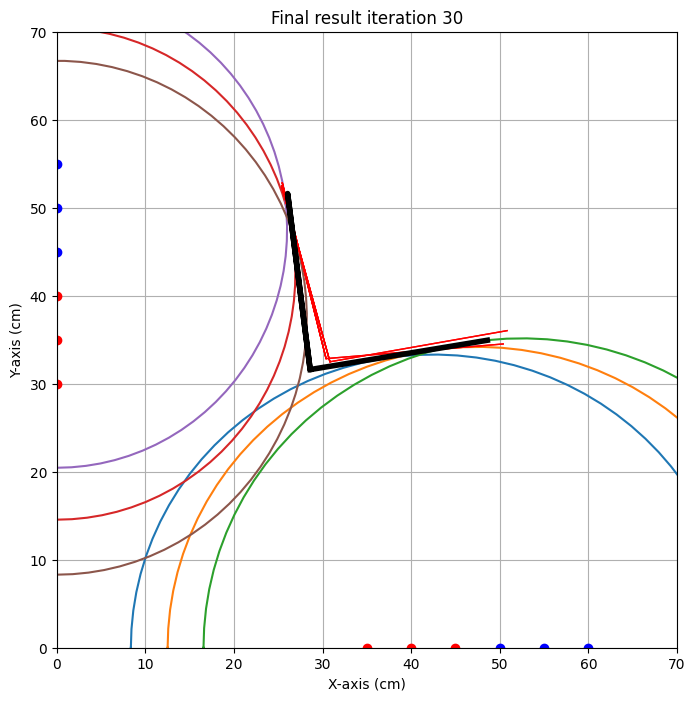

{'alpha': np.float64(9.451101879733116), 'alpha_eps': np.float64(4.6988311086698245), 'beta': np.float64(-7.256160967419647), 'beta_eps': np.float64(8.027780764074944), 'x0': np.float64(28.593608295610547), 'x0_eps': np.float64(2.2337227170188356), 'y0': np.float64(31.608815701127607), 'y0_eps': np.float64(1.2457422954911372)}
test locatie 
x0 target is : 31.2. Gevonden waarde: 28.6 cm met een standaardafwijking van 2.2 cm 
y0 target is : 32.5. Gevonden waarde: 31.6 cm met een standaardafwijking van 1.2 cm 
alpha target is : 7.0. Gevonden waarde: 9.5 graden met een standaardafwijking van 4.7 graad 
beta target is : -18.0. Gevonden waarde: -7.3 graden met een standaardafwijking van 8.0 graad 



In [10]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  31.2, 
                    'y0':  32.5, 
                    'alpha' :  7, 
                    'beta' :  -18,
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [35,0,50,0,68.3],
                    [40,0,55,0,70],
                    #[30,0,45,0,ongeldig],
                    [45,0,60,0,71.9],
                    [0,35,0,50,55.9],
                    [0,40,0,55,54.1],
                    [0,30,0,45,58.4],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
#### algoritme [Lars Mulder]
<img src="Algoritme_Lars.jpeg" width="400">

#### algoritme [Elisabeth Mijnders]
<img src="Algoritme_Elisabeth.jpeg" width="400">

#### algoritme [Oscar Pouw]
<img src="Algoritme_Oscar.jpg" width="400">


samenvoeging van alle 0e iteraties bij elkaar. als er een meting gedaan is een aantal extra metingen (met 5 cm afstand) in een kleine omgeving doen.
## Figuur: iteratie 1 ![Alt](Iteratie1.jpeg) 

bij deze iteratie hebben we de afstand vergroot tussen de bron en ontvanger om het bereik te vergroten. ook is de afstand tussen de metingen verkleind (van 5 cm naar 2.5cm) om zo de onzekerheid te verkleinen 
## Figuur: iteratie 2 ![Alt](Iteratie2.jpeg)

Bij deze iteratie zijn er maar 2 metingen om een gemeten punt gemeten in plaats van 4 en is de afstand tussen deze punten weer groter dan bij iteratie 2 (weer van 2.5 naar 5 cm). Dit is gedaan om de onzekerheid te verkleinen, want meer punten leverde een grotere onzekerheid op.
## Figuur: iteratie 3 ![Alt](iteratie3.jpeg)

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  35   0  50   0  68.3
1  40   0  55   0  70.0
2  45   0  60   0  71.9
3   0  35   0  50  55.9
4   0  40   0  55  54.1
5   0  30   0  45  58.4


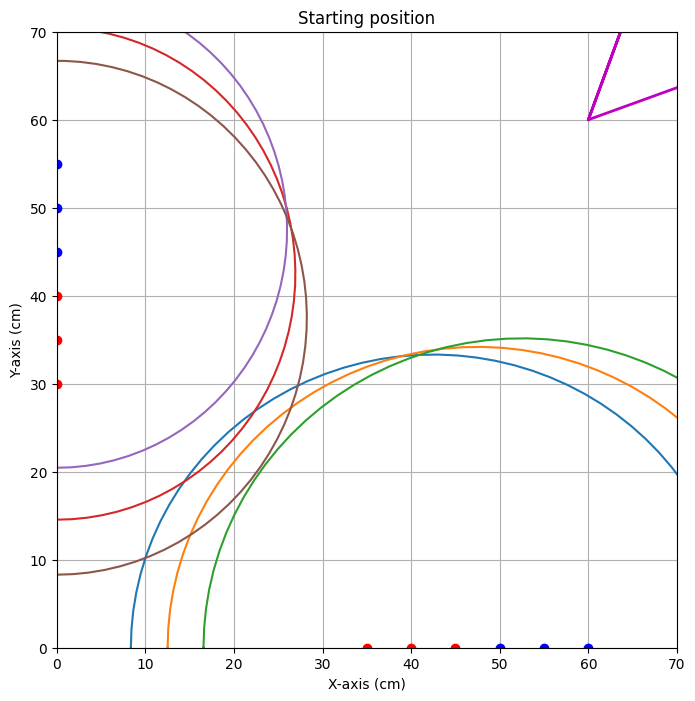


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.392


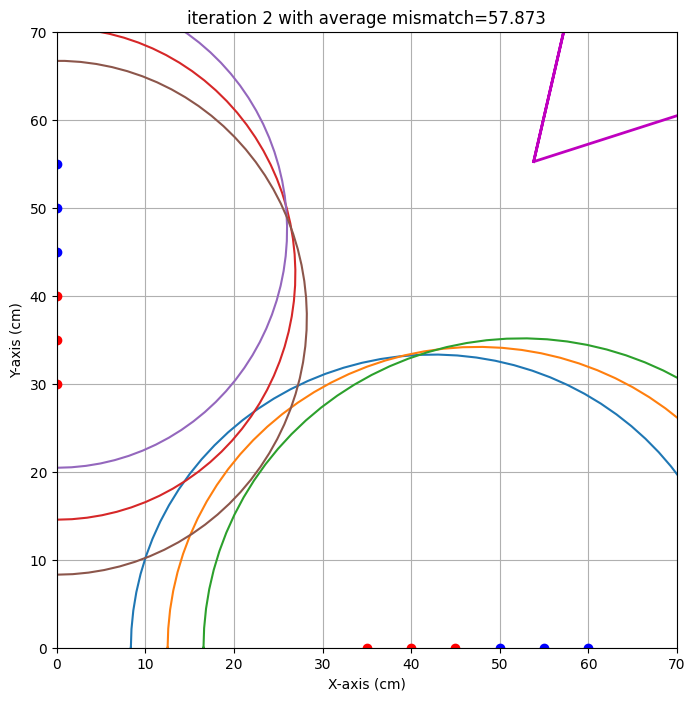

end iteration 2 with average mismatch=57.873


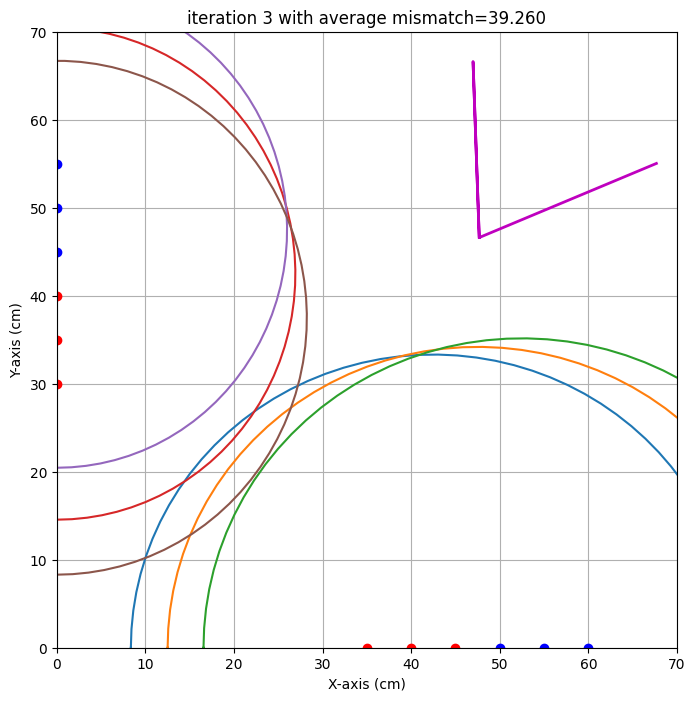

end iteration 3 with average mismatch=39.260


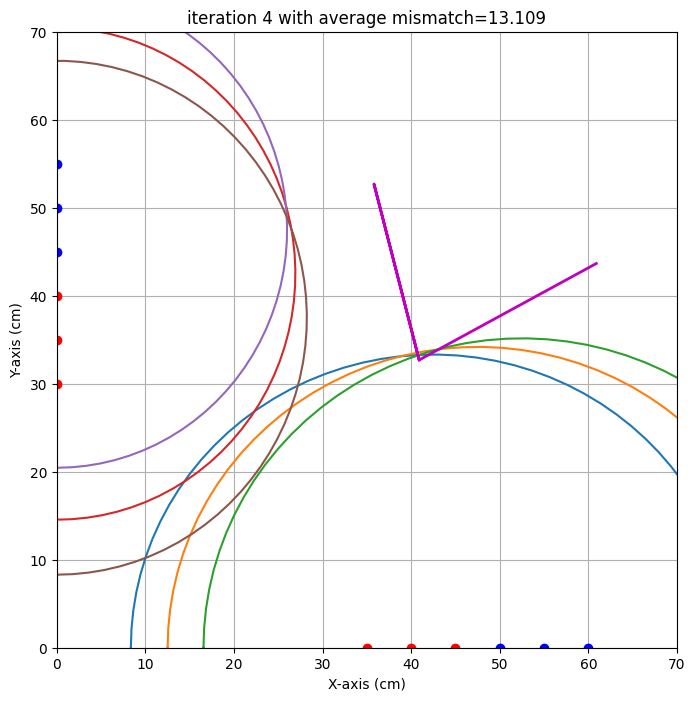

end iteration 4 with average mismatch=13.109


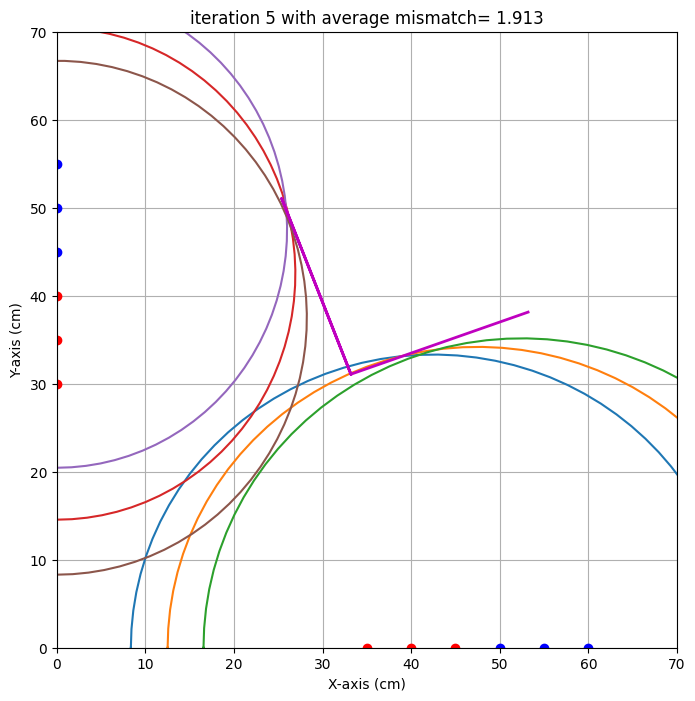

end iteration 5 with average mismatch= 1.913


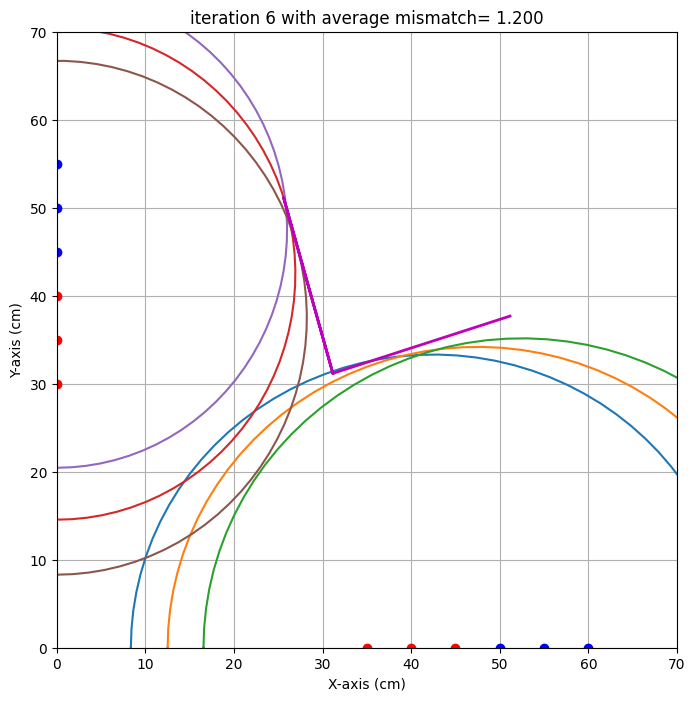

end iteration 6 with average mismatch= 1.200


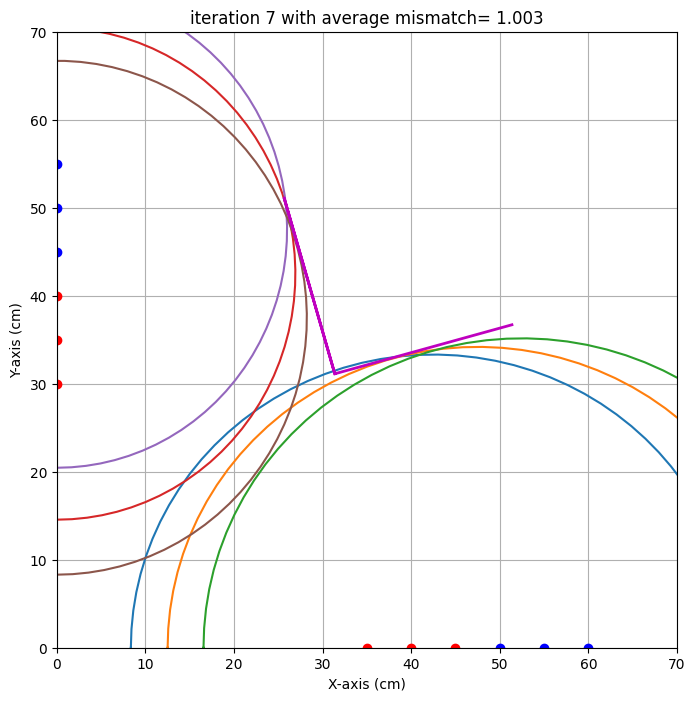

end iteration 7 with average mismatch= 1.003
end iteration 8 with average mismatch= 0.978


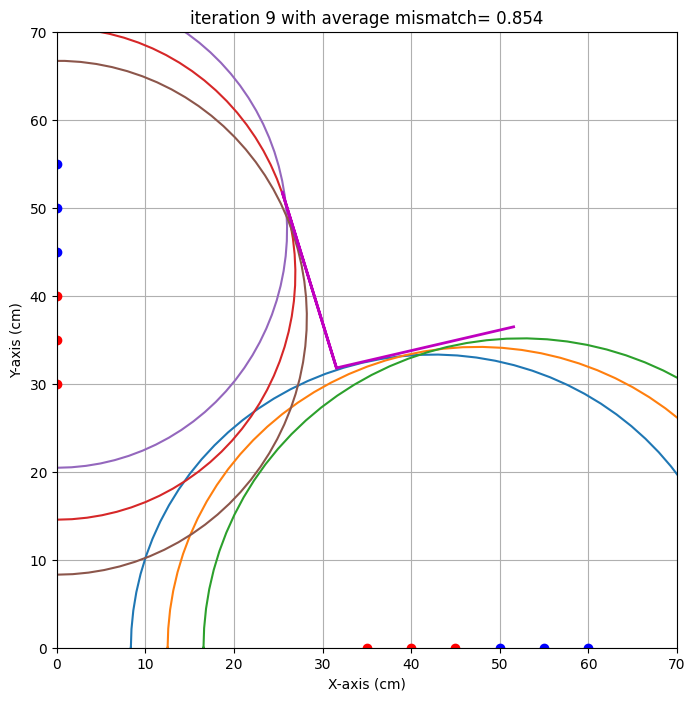

end iteration 9 with average mismatch= 0.854
end iteration 10 with average mismatch= 0.805


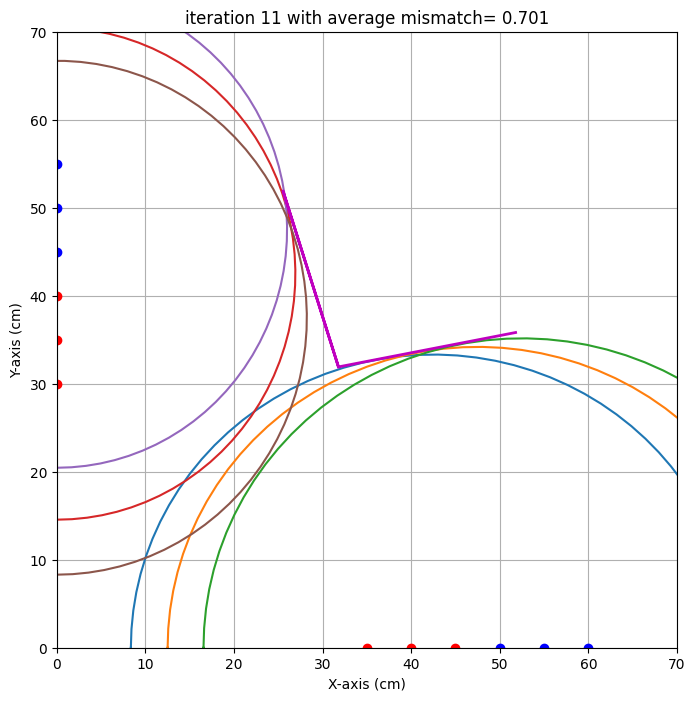

end iteration 11 with average mismatch= 0.701
end iteration 12 with average mismatch= 0.635
end iteration 13 with average mismatch= 0.628
end iteration 14 with average mismatch= 0.603
end iteration 15 with average mismatch= 0.548


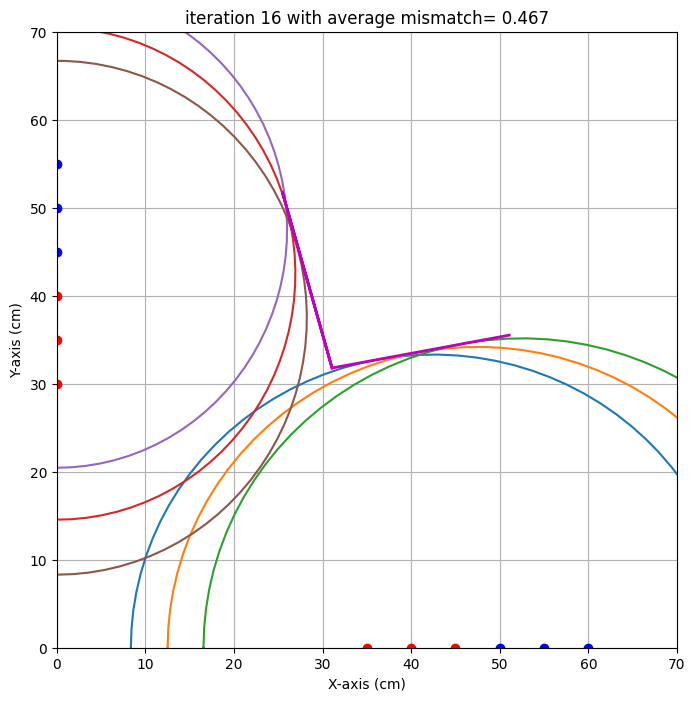

end iteration 16 with average mismatch= 0.467
end iteration 17 with average mismatch= 0.464
end iteration 18 with average mismatch= 0.464
end iteration 19 with average mismatch= 0.464
end iteration 20 with average mismatch= 0.464
end iteration 21 with average mismatch= 0.464
end iteration 22 with average mismatch= 0.464
end iteration 23 with average mismatch= 0.464
end iteration 24 with average mismatch= 0.464
end iteration 25 with average mismatch= 0.464
end iteration 26 with average mismatch= 0.464
end iteration 27 with average mismatch= 0.464
end iteration 28 with average mismatch= 0.446
end iteration 29 with average mismatch= 0.444
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.443
###############################################################################
end of iteration  30
Best alpha=  10.01 with uncertainty=   0.45
Best beta = -14.52 with uncertainty=   2.59
Best x0   = 

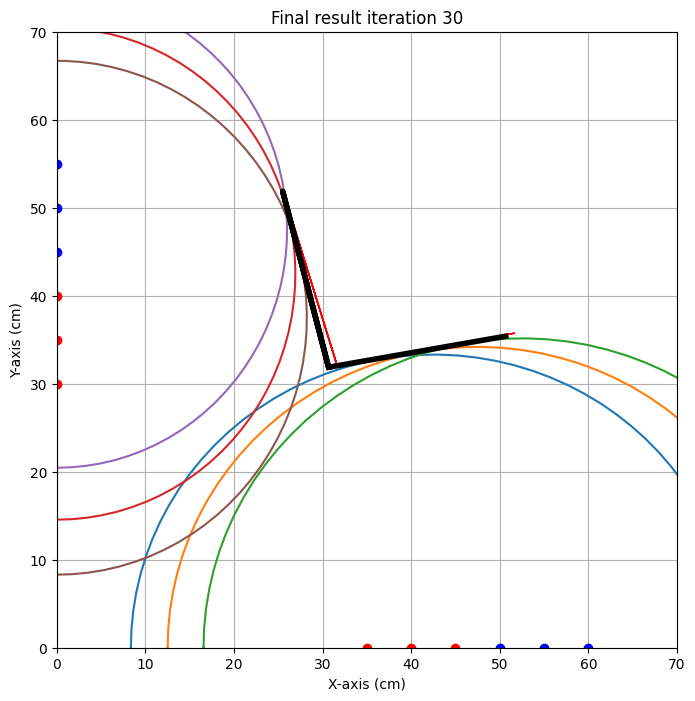

{'alpha': np.float64(10.008419145171434), 'alpha_eps': np.float64(0.4542610337980584), 'beta': np.float64(-14.52365969910715), 'beta_eps': np.float64(2.585144170696651), 'x0': np.float64(30.670090181184428), 'x0_eps': np.float64(0.9737411227354009), 'y0': np.float64(31.870663828702064), 'y0_eps': np.float64(0.1734257486868529)}
test locatie 
x0 target is : 31.2. Gevonden waarde: 30.7 cm met een standaardafwijking van 1.0 cm 
y0 target is : 32.5. Gevonden waarde: 31.9 cm met een standaardafwijking van 0.2 cm 
alpha target is : 7.0. Gevonden waarde: 10.0 graden met een standaardafwijking van 0.5 graad 
beta target is : -18.0. Gevonden waarde: -14.5 graden met een standaardafwijking van 2.6 graad 



In [11]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  31.2, 
                    'y0':  32.5, 
                    'alpha' :  7, 
                    'beta' :  -18,
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [35,0,50,0,68.3],
                    [40,0,55,0,70],
                    #[30,0,45,0,ongeldig],
                    [45,0,60,0,71.9],
                    [0,35,0,50,55.9],
                    [0,40,0,55,54.1],
                    [0,30,0,45,58.4],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))